In [1]:
import os 
import sys
import multiprocessing
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.datasets import Mante, Mante_Teacher
from vi_rnn.saving import save_model, load_model

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params


%matplotlib inline

In [2]:
figures_dir = '../../figures'
cuda = False  # toggle if GPU is available
device = 'cpu'
neuromodulation_mechanisms = ['additive', 'rank', 'presynaptic', 'postsynaptic'] # one of 'rank', 'presynaptic', 'postsynaptic', 'additive'
train_nm_params = True
train_batches = 4

### Generate teacher data for each neuromodulation mechanism

In [3]:
train_teacher = False
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 3000
model_params["n_inp"] = 2
training_params["l2_rates_reg"] = 0.1
model_params['rank']= 1
model_params['ds'] = 2
model_params["train_b_rec"] = False # don't train the neuron biases

data_dir = {}
teachers = {}
teacher_model_params = {} 
teacher_task_params = {} 
teacher_training_params = {} 
teacher_tasks = {}
perturb_params = [[0.1, 0.25], [0.1, 0.25], [0.1, 0.25], [0.1, 0.25]]

for i, mech in enumerate(neuromodulation_mechanisms):
    data_dir[mech] = f"../../data/mante_{mech}_rank_{model_params['rank']}/"
    teachers[mech], teacher_model_params[mech], teacher_task_params[mech], teacher_training_params[mech] = load_rnn(
        data_dir[mech] + f"rnn_mante_{mech}_rank_{model_params['rank']}_2"
    )
    batch_size = 4
    task_params = {
        "name": "mante",
        "n_neurons": teachers[mech].rnn.N,
        "out": "currents",
        "r0": 0,
        "R_x": 0.1,
        "R_z": 0.05,
        "n_trials": 400,
        "du": model_params["n_inp"],
        "dz": model_params["rank"],
        "neuromodulation": mech
    }
    rnn = teachers[mech]
    U, V, B = extract_orth_basis_rnn(rnn)
    I = rnn.rnn.w_inp.detach()
    A = rnn.rnn.A.detach() 

    with torch.no_grad():
        teacher_tasks[mech] = Mante_Teacher(task_params, 
                                            teacher_task_params[mech], 
                                            U, V, B, I, A, 
                                            decay=0.9, 
                                            perturb=False,
                                            )

model_dir = "../../models/students/"

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\py_rnn\train.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torc

### Define Mante task

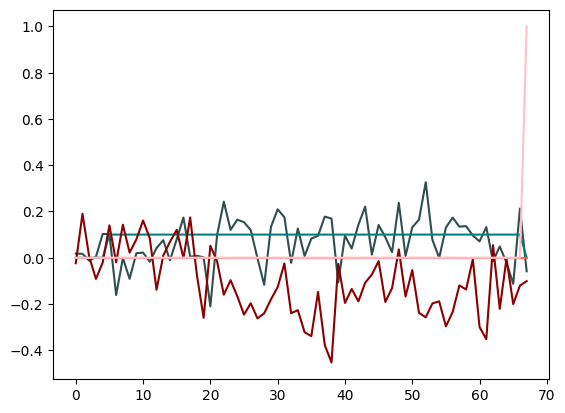

In [4]:
# Plot an example trial for teacher RNN

task_params_teacher = {
    "name": "mante",
    "fixation_dur":5,
    "stimulus_dur":40,
    "delay_dur":5,
    "response_dur":1,
    "std":.1,
    "scale":.1}
# rdm = RDM(task_params_teacher)
mante = Mante(task_params_teacher)
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

### Plot latent trajectories for teacher training samples

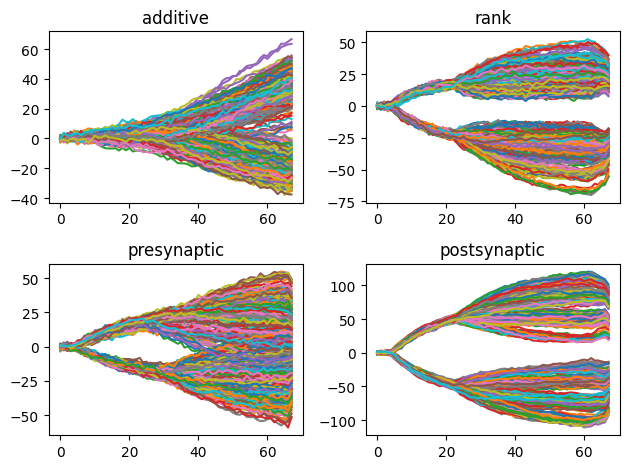

In [5]:
fig, ax = plt.subplots(2, 2)
i, j = 0, 0
for idx, mech in enumerate(neuromodulation_mechanisms):
    z = teacher_tasks[mech].data @ teachers[mech].rnn.m 
    for b in range(z.shape[0]):
        trial_latent = z[b].detach()
        if trial_latent.min() < -300: continue
        ax[i, j].plot(np.arange(0, len(trial_latent)), trial_latent)
        ax[i, j].set_title(mech)
    j += 1
    if j > 1: i, j = i + 1, 0
plt.tight_layout()

In [7]:
trained = ["additive_additive", "additive_rank", "additive_presynaptic", "additive_postsynaptic", "rank_additive"]
for teacher_mech in neuromodulation_mechanisms:
    for student_mech in neuromodulation_mechanisms:
        print(f'Teacher mechanism: {teacher_mech}. Student mechanism: {student_mech}')
        # Initialise VI / student setup
        dim_z = teacher_model_params[teacher_mech]["rank"]
        dim_N = teacher_model_params[teacher_mech]["n_rec"]
        dim_x = teacher_model_params[teacher_mech]["n_rec"]
        dim_u = teacher_model_params[teacher_mech]["n_inp"]
        dim_s = teacher_model_params[teacher_mech]["ds"]

        n_epochs = 150
        wandb = False
        # initialise encoder
        enc_params = {"obs_grad": True, "init_scale": 0.1}

        # initialise prior
        prior_params = {
            "train_noise_x": True,
            "train_noise_z": True,
            "train_noise_z_t0": True,
            "init_noise_z": 0.05,
            "init_noise_z_t0": 1,
            "init_noise_x": 0.1,
            "scalar_noise_z": "Cov",
            "scalar_noise_x": False,
            "scalar_noise_z_t0": "Cov",
            "identity_readout": True,
            "activation": "relu",
            "exp_par": True,
            "shared_tau": 0.7,
            "readout_rates": 'currents',
            "train_obs_bias": False,
            "train_obs_weights": False,
            "train_latent_bias": False,
            "train_neuron_bias": True,
            "orth": False,
            "m_norm": False,
            "weight_dist": "uniform",
            "weight_scaler": 1,  # /dim_N,
            "initial_state": "trainable",
            "out_nonlinearity": "identity",
            "neuromodulation": student_mech,
            "train_nm_params": train_nm_params
        }

        training_params = {
            "lr": 1e-3,
            "step_size": 6, 
            "gamma": 0.94,
            "lr_end": 1e-7,
            "opt_eps": 1e-8,
            "n_epochs": n_epochs,
            "grad_norm": 0,
            "bootstrap": False,
            "eval_epochs": 10,
            "batch_size": 10,
            "cuda": cuda,
            "smoothing": 20,
            "freq_cut_off": 10000,
            "sim_obs_noise": 0,
            "sim_latent_noise": 1,
            "k": 64, 
            "loss_f": "opt_VGTF",
            "resample": "systematic",  # , multinomial or none"
            "run_eval": False,
            "smooth_at_eval": False,
            "neuromodulation": student_mech,
            "sim_v": True,
            "verbose": True
        }

        VAE_params = {
            "dim_x": dim_x,
            "dim_z": dim_z,
            "dim_u": dim_u,
            "dim_N": dim_N,
            "dim_s": dim_s,
            "enc_architecture": "Inv_Obs",
            "enc_params": enc_params,
            "prior_architecture": "PLRNN",
            "prior_params": prior_params,
            "causal": True,
        }
        vae = VAE(VAE_params)
        train_VAE(
            vae,
            training_params,
            teacher_tasks[teacher_mech],
            eval_task=None,
            sync_wandb=wandb,
            out_dir=model_dir,
            fname=f"mante_{teacher_mech}_{student_mech}_3",
            store_train_stats=False,
        )

Teacher mechanism: additive. Student mechanism: additive
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
Training on : cpu
Learning rate decay factor 0.9404448517263517
epoch 1 loss: 554.9509, ll: -554.9509, ll_x: 553.8424, ll_z: -1.5328 H: 2.5545, alpha: 0.81, lr: 0.001000, N_z: 0.0501, N_x: 0.1027
epoch 2 loss: 544.6841, ll: -544.6841, ll_x: 543.7675, ll_z: -1.6808 H: 2.5510, alpha: 0.81, lr: 0.001000, N_z: 0.0501, N_x: 0.1030
epoch 3 loss: 536.0627, ll: -536.0627, ll_x: 535.2494, ll_z: -1.7607 H: 2.5493, alpha: 0.81, lr: 0.001000, N_z: 0.0500, N_x: 0.1034
epoch 4 loss: 525.4762, ll: -525.4762, ll_x: 524.7198, ll_z: -1.8044 H: 2.5473, alpha: 0.80, lr: 0.001000, N_z: 0.0497, N_x: 0.1039
epoch 5 loss: 513.3649, ll: -513.3649, ll_x: 512.6399, ll_z: -1.8280 H: 2.5449, alpha: 0.80, lr: 0.001000, N_z: 0.0494, N_x: 0.1044
epoch 6 loss: 500.0292, ll: -500.0292, ll_x: 499.3252, ll_z: -1.8439 H: 2.5424, alpha: 0.80, lr: 0.001000, N_z: 0.0491, N_x: 0.1050

### Load all stored models

In [13]:
teacher_mechas = ["additive", "postsynaptic", "rank", "presynaptic"]
student_mechas = ["additive", "postsynaptic", "rank", "presynaptic"]

student_models = {}
for tm in teacher_mechas:
    for sm in student_mechas:
        model, vae_params, task_params, training_params = load_model(name=f"../../models/students/mante_{tm}_{sm}_3")
        student_models[f"{tm}_{sm}"] = model    

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: postsynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: rank
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: presynaptic
using ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

### Get predictions for each trial/batch

In [158]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from evaluation.kl_Gauss import calc_kl_from_data

predictions = torch.zeros((len(neuromodulation_mechanisms), 
                           len(neuromodulation_mechanisms),
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[0],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[1],
                           teacher_tasks[neuromodulation_mechanisms[0]].data.shape[2]
                           ))

for i, tm in enumerate(neuromodulation_mechanisms):
    for j, sm in enumerate(neuromodulation_mechanisms):
        # if i != j: continue 
        student = student_models[f"{tm}_{sm}"]
        X_pred = torch.zeros_like(teacher_tasks[tm].data) 
        student.eval() 
    
        for b in range(teacher_tasks[tm].data.shape[0]):
            X_pred[b] = predict_X(
                student,
                teacher_tasks[tm].data.size(1),
                teacher_tasks[tm].data[b].T,
                teacher_tasks[tm].stim[b].T.unsqueeze(0),
                teacher_tasks[tm].s[b].T.unsqueeze(0),
            ).reshape(teacher_model_params[tm]["n_rec"], -1).T

        predictions[i, j] = X_pred

In [254]:
num_neurons = 60
r2_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), num_neurons)
pr_scores = torch.zeros_like(r2_scores)
kl_scores = torch.zeros(len(neuromodulation_mechanisms), len(neuromodulation_mechanisms), 1)

for i, tch in enumerate(neuromodulation_mechanisms):
    targ = teacher_tasks[tch].data.reshape(-1, num_neurons)
    for j, std in enumerate(neuromodulation_mechanisms):
        pred = predictions[i, j].reshape(-1, num_neurons)
        r2_scores[i, j] = torch.tensor([r2_score(targ[:, i], pred[:, i]) for i in range(num_neurons)])
        pr_scores[i, j] = torch.tensor([pearsonr(targ[:, i], pred[:, i])[0] for i in range(num_neurons)])
        kl_scores[i, j] = torch.tensor([calc_kl_from_data(pred, targ)])


n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0
n outliers: 0.0020000000000000018
n outliers: 0.0010000000000000009
n outliers: 0.0020000000000000018
n outliers: 0.0020000000000000018


In [269]:
def plot_histogram(tch_idx, scores, fig_title):
    for i in range(len(neuromodulation_mechanisms)):
        plt.hist(scores[tch_idx, i], alpha=0.5, bins=np.linspace(-1, 1, 20), label=neuromodulation_mechanisms[i])
    plt.title(fig_title)
    plt.legend()

def plot_bar(scores, tch_idx, fig_title):
    plt.bar(['additive', 'rank', 'presynaptic', 'postsynaptic'], scores[tch_idx].flatten())
    plt.title(fig_title)

### Teacher: Additive modulated RNN

#### KL-Divergence plots

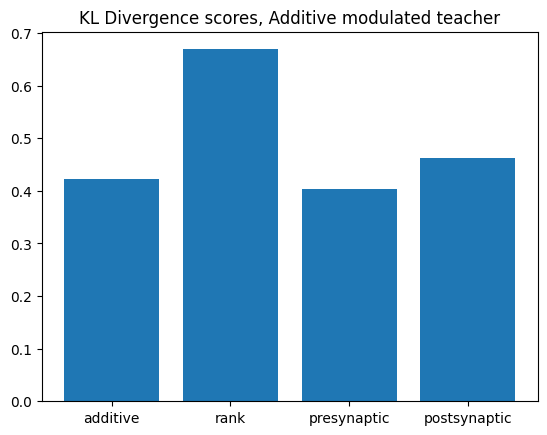

In [270]:
plot_bar(kl_scores, 0, 'KL Divergence scores, Additive modulated teacher')

#### $R^2$ histograms

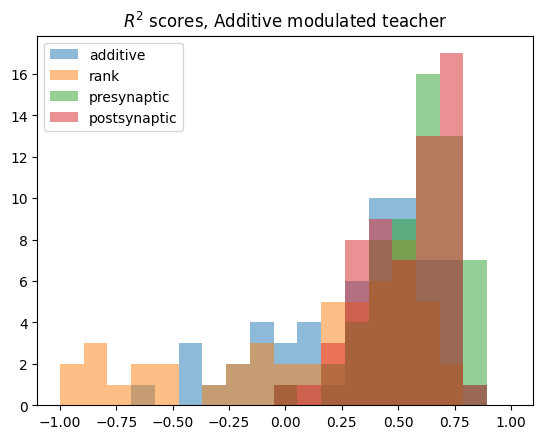

In [273]:
plot_histogram(0, r2_scores, '$R^2$ scores, Additive modulated teacher')

#### Pearson's R bar plots

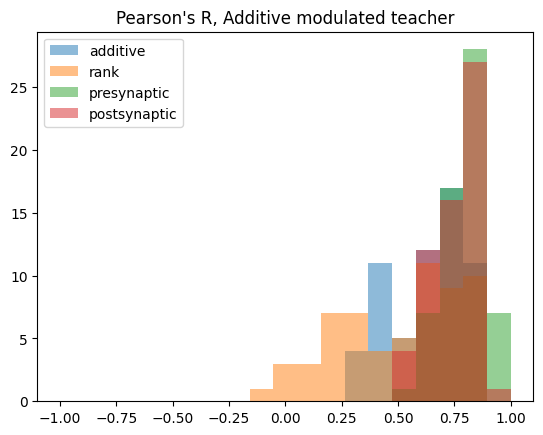

In [272]:
plot_histogram(0, pr_scores, "Pearson's R, Additive modulated teacher")

### Teacher: Rank Neuromodulated RNN

#### KL-Divergence

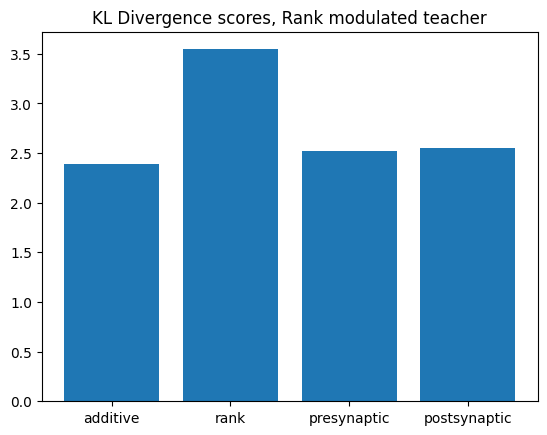

In [276]:
plot_bar(kl_scores, 1, fig_title="KL Divergence scores, Rank modulated teacher")

#### $R^2$

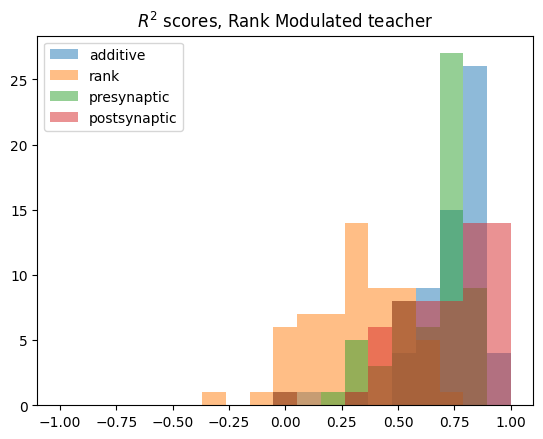

In [282]:
plot_histogram(1, r2_scores, fig_title="$R^2$ scores, Rank Modulated teacher")

#### Pearson's R

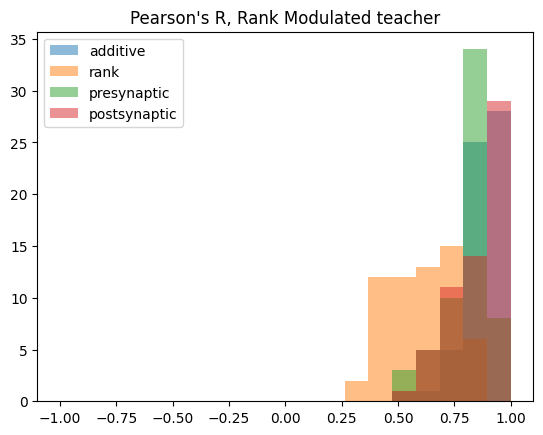

In [283]:
plot_histogram(1, pr_scores, fig_title="Pearson's R, Rank Modulated teacher")

## Teacher: Presynaptic modulated RNN

#### KL-Divergence

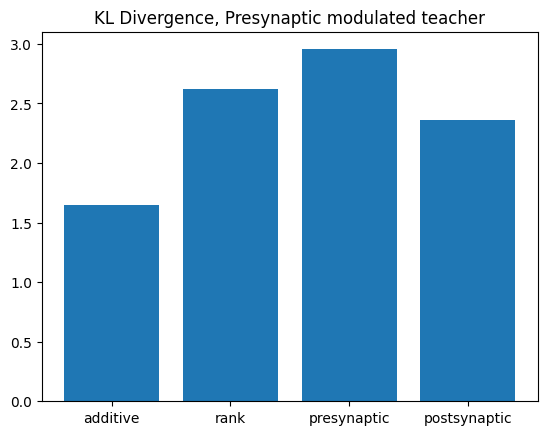

In [285]:
plot_bar(kl_scores, 2, "KL Divergence, Presynaptic modulated teacher")

$R^2$

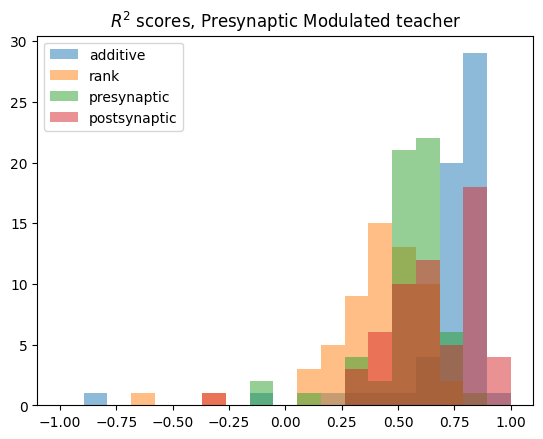

In [286]:
plot_histogram(2, r2_scores, fig_title="$R^2$ scores, Presynaptic Modulated teacher")

#### Pearson's R

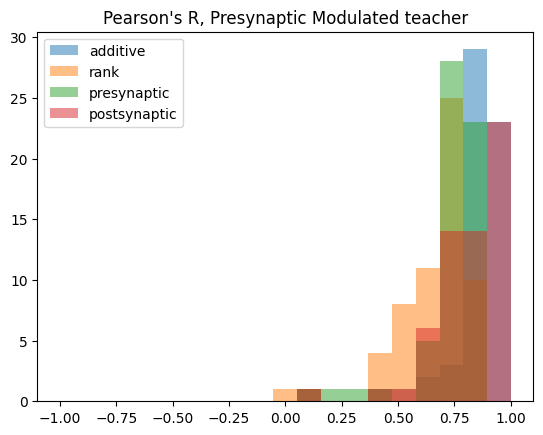

In [292]:
plot_histogram(2, pr_scores, fig_title="Pearson's R, Presynaptic Modulated teacher")

## Teacher: Postsynaptic Teacher

#### KL Divergence

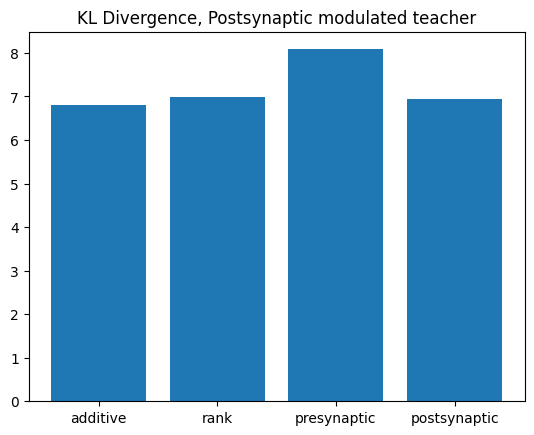

In [288]:
plot_bar(kl_scores, 3, "KL Divergence, Postsynaptic modulated teacher")

#### $R^2$ scores

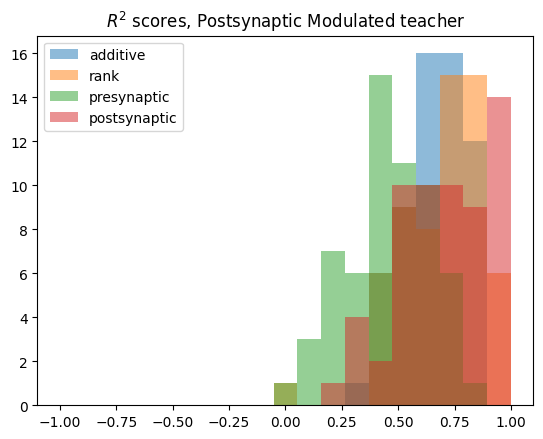

In [290]:
plot_histogram(3, r2_scores, fig_title="$R^2$ scores, Postsynaptic Modulated teacher")

#### Pearson's R

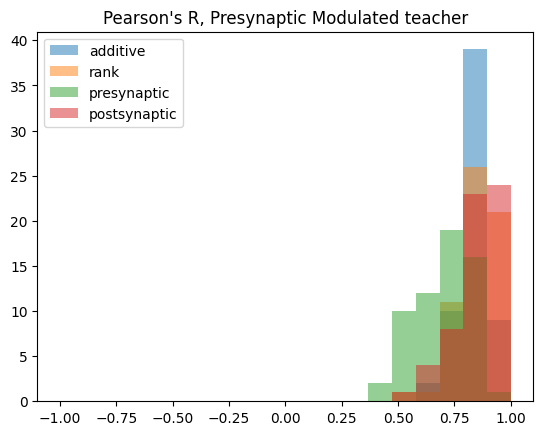

In [293]:
plot_histogram(3, pr_scores, fig_title="Pearson's R, Presynaptic Modulated teacher")

## KL-Divergence table

In [295]:
np.median(kl_scores, axis=2)

array([[0.42299634, 0.66897243, 0.40311047, 0.4632302 ],
       [2.387649  , 3.5444531 , 2.5211368 , 2.5501695 ],
       [1.6457446 , 2.6182156 , 2.9540632 , 2.3636267 ],
       [6.8021226 , 6.9802184 , 8.083999  , 6.952344  ]], dtype=float32)

## $R^2$ scores table

In [296]:
np.median(r2_scores, axis=2)

array([[0.42591268, 0.17398056, 0.6160578 , 0.57992446],
       [0.79007936, 0.30392516, 0.7225144 , 0.76055616],
       [0.7882184 , 0.43883607, 0.56865585, 0.6444188 ],
       [0.66851544, 0.71880317, 0.4612397 , 0.7004608 ]], dtype=float32)

## Pearson's R scores table

In [297]:
np.median(pr_scores, axis=2)

array([[0.67848146, 0.57366   , 0.8042052 , 0.7799088 ],
       [0.8914238 , 0.60683167, 0.85424244, 0.884411  ],
       [0.8904898 , 0.7052577 , 0.7649326 , 0.8207463 ],
       [0.84012073, 0.87034106, 0.70860565, 0.85976297]], dtype=float32)

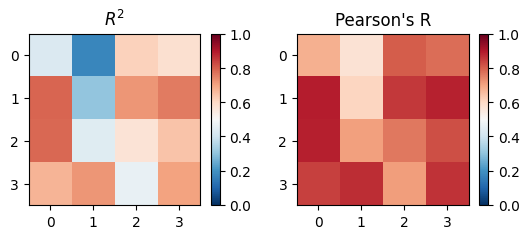

In [313]:
fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot(1,3,1)
plt.imshow(np.median(r2_scores, axis=2),vmin=0,vmax=1, cmap="RdBu_r")
plt.colorbar(shrink=0.3)
ax0.set_title("$R^2$")

ax1 = plt.subplot(1,3,2)
plt.imshow(np.median(pr_scores, axis=2),vmin=0,vmax=1, cmap="RdBu_r")
plt.colorbar(shrink=0.3)
ax1.set_title("Pearson's R")

plt.tight_layout()

#### Perform T-tests to determine significance of each cell versus the diagonal 

In [319]:
from scipy.stats import ttest_rel

t_stats_r2 = np.zeros((len(neuromodulation_mechanisms), len(neuromodulation_mechanisms)))
t_stats_pr = np.zeros_like(t_stats_r2)

p_vals_r2 = np.zeros_like(t_stats_r2)
p_vals_pr = np.zeros_like(p_vals_r2)

for i, tm in enumerate(neuromodulation_mechanisms):
    for j, tm in enumerate(neuromodulation_mechanisms):
        if i == j: continue 
        t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, j], r2_scores[i, i])
        t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, j], pr_scores[i, i])

        t_stats_r2[i, j], t_stats_pr[i, j] = t_stat_r2, t_stat_pr 
        p_vals_r2[i, j], p_vals_pr[i, j] = p_val_r2, p_val_pr 

#### Significance test for the $R^2$ scores

In [322]:
t_stats_r2

array([[ 0.        , -7.39969841,  7.25512521,  5.25339153],
       [13.92388322,  0.        ,  9.75585411,  9.69645087],
       [14.15489822, -6.78949487,  0.        ,  4.87617828],
       [-2.78652835, -1.05552237, -7.01187297,  0.        ]])

In [323]:
p_vals_r2

array([[0.00000000e+00, 5.68880542e-10, 1.00020797e-09, 2.15037940e-06],
       [2.65863916e-20, 0.00000000e+00, 6.43709468e-14, 8.05453057e-14],
       [1.25483424e-20, 6.13947051e-09, 0.00000000e+00, 8.53362734e-06],
       [7.15474508e-03, 2.95489636e-01, 2.58301997e-09, 0.00000000e+00]])

#### Significance test for Pearson's R scores

In [324]:
t_stats_pr

array([[ 0.        , -6.35193539,  7.79589121,  5.60359281],
       [11.79652058,  0.        ,  8.38238126,  8.94039956],
       [12.38243731, -5.09865359,  0.        ,  5.22309708],
       [-1.98433801, -0.14987297, -6.91202086,  0.        ]])

In [325]:
p_vals_pr

array([[0.00000000e+00, 3.34607198e-08, 1.21216556e-10, 5.81992910e-07],
       [3.68769067e-17, 0.00000000e+00, 1.23813534e-11, 1.43611298e-12],
       [4.74552893e-18, 3.80052070e-06, 0.00000000e+00, 2.40501319e-06],
       [5.18755152e-02, 8.81376007e-01, 3.81122105e-09, 0.00000000e+00]])

### Comparison of additive neuromodulation model vs rank neuromodulation model

In [331]:
for i, tm in enumerate(neuromodulation_mechanisms): 
    t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, 0], r2_scores[i, 1])
    t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, 0], pr_scores[i, 1])
    print(f'Teacher {tm}: R2 T-statistic: {t_stat_r2}, p-value = {p_val_r2}. Pearson R T-statistic: {t_stat_pr}, p-value = {p_val_pr}')

Teacher additive: R2 T-statistic: 7.399698405313255, p-value = 5.688805416910467e-10. Pearson R T-statistic: 6.351935393014965, p-value = 3.346071983378439e-08
Teacher rank: R2 T-statistic: 13.923883220330568, p-value = 2.6586391621145054e-20. Pearson R T-statistic: 11.796520577989961, p-value = 3.687690670965472e-17
Teacher presynaptic: R2 T-statistic: 15.007763193728128, p-value = 8.319316982589564e-22. Pearson R T-statistic: 12.70019333279975, p-value = 1.589647216304658e-18
Teacher postsynaptic: R2 T-statistic: -1.8052446543030716, p-value = 0.07613945577396172. Pearson R T-statistic: -1.9374366718538965, p-value = 0.057483584159173914


### Comparison of postsynaptic neuromodulation model vs rank neuromodulation model

In [332]:
for i, tm in enumerate(neuromodulation_mechanisms): 
    t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, 3], r2_scores[i, 1])
    t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, 3], pr_scores[i, 1])
    print(f'Teacher {tm}: R2 T-statistic: {t_stat_r2}, p-value = {p_val_r2}. Pearson R T-statistic: {t_stat_pr}, p-value = {p_val_pr}')

Teacher additive: R2 T-statistic: 7.0269847877997975, p-value = 2.4352764331300265e-09. Pearson R T-statistic: 6.800591566305877, p-value = 5.880167547668487e-09
Teacher rank: R2 T-statistic: 9.696450873383915, p-value = 8.054530569558768e-14. Pearson R T-statistic: 8.940399556074835, p-value = 1.4361129776390506e-12
Teacher presynaptic: R2 T-statistic: 6.498056846511562, p-value = 1.9022185137558868e-08. Pearson R T-statistic: 6.039811668246904, p-value = 1.1105970187744024e-07
Teacher postsynaptic: R2 T-statistic: 1.0555223677140073, p-value = 0.295489636164718. Pearson R T-statistic: 0.14987297194795815, p-value = 0.8813760071238643


#### Comparison of postsynaptic and additive models

In [333]:
for i, tm in enumerate(neuromodulation_mechanisms): 
    t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, 3], r2_scores[i, 0])
    t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, 3], pr_scores[i, 0])
    print(f'Teacher {tm}: R2 T-statistic: {t_stat_r2}, p-value = {p_val_r2}. Pearson R T-statistic: {t_stat_pr}, p-value = {p_val_pr}')

Teacher additive: R2 T-statistic: 5.253391533152046, p-value = 2.1503794004196087e-06. Pearson R T-statistic: 5.603592813680363, p-value = 5.819929102629969e-07
Teacher rank: R2 T-statistic: -2.3878905034636806, p-value = 0.020165977716040624. Pearson R T-statistic: -1.789324076294913, p-value = 0.07869560672354549
Teacher presynaptic: R2 T-statistic: -4.253590015000717, p-value = 7.617790653439425e-05. Pearson R T-statistic: -3.8000389007871758, p-value = 0.00034473837676014986
Teacher postsynaptic: R2 T-statistic: 2.7865283452457903, p-value = 0.007154745080217139. Pearson R T-statistic: 1.9843380136438729, p-value = 0.05187551520153531


### Comparison of additive and presynaptic models

In [341]:
for i, tm in enumerate(neuromodulation_mechanisms): 
    t_stat_r2, p_val_r2 = ttest_rel(r2_scores[i, 0], r2_scores[i, 2])
    t_stat_pr, p_val_pr = ttest_rel(pr_scores[i, 0], pr_scores[i, 2])
    print(f'Teacher {tm}: R2 T-statistic: {t_stat_r2}, p-value = {p_val_r2}. Pearson R T-statistic: {t_stat_pr}, p-value = {p_val_pr}')

Teacher additive: R2 T-statistic: -7.255125208470143, p-value = 1.0002079666750245e-09. Pearson R T-statistic: -7.795891213536434, p-value = 1.212165556430517e-10
Teacher rank: R2 T-statistic: 7.882383628602976, p-value = 8.652105095652588e-11. Pearson R T-statistic: 7.087993425104782, p-value = 1.919780833226406e-09
Teacher presynaptic: R2 T-statistic: 14.154898222906898, p-value = 1.2548342443296623e-20. Pearson R T-statistic: 12.382437314989204, p-value = 4.74552893221813e-18
Teacher postsynaptic: R2 T-statistic: 7.605609261471614, p-value = 2.5465890806839563e-10. Pearson R T-statistic: 7.983496560047305, p-value = 5.834994946579062e-11


Text(0.5, 1.0, 'Recovering Input weights')

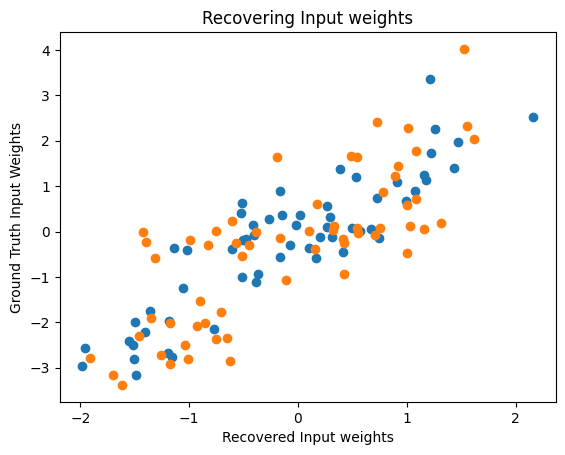

In [233]:
plt.scatter(student_models["additive_additive"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["additive"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["additive_additive"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["additive"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering Input weights')

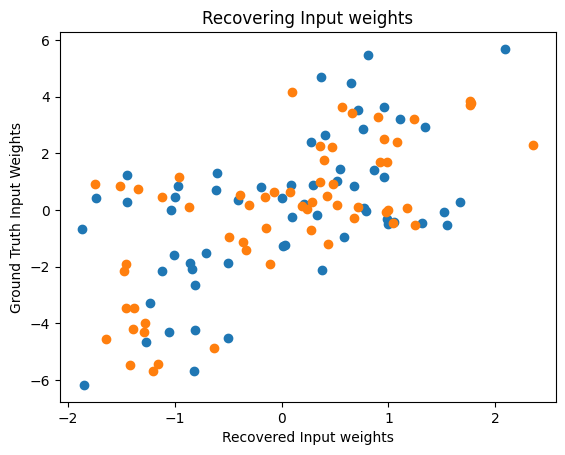

In [234]:
plt.scatter(student_models["presynaptic_additive"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["presynaptic"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["presynaptic_additive"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["presynaptic"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering Input weights')

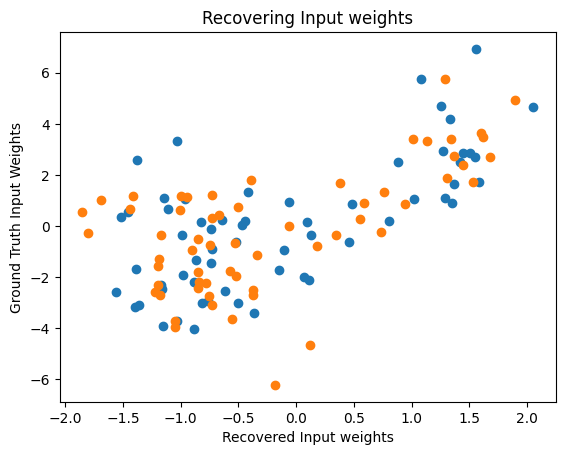

In [237]:
plt.scatter(student_models["rank_presynaptic"].rnn.transition.Wu[:, 0].detach().numpy(), teachers["rank"].rnn.w_inp[0, :].detach())
plt.scatter(student_models["rank_presynaptic"].rnn.transition.Wu[:, 1].detach().numpy(), teachers["rank"].rnn.w_inp[1, :].detach())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

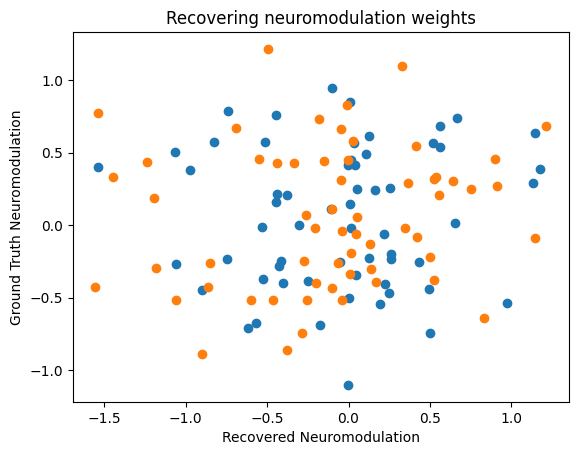

In [340]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 0].detach().numpy())
plt.scatter(student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

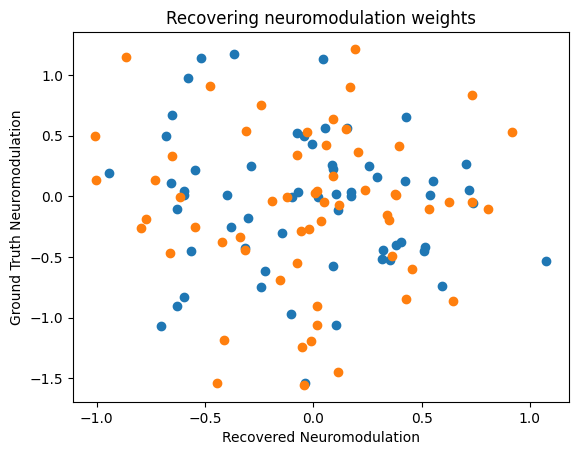

In [246]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 0].detach().numpy())
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

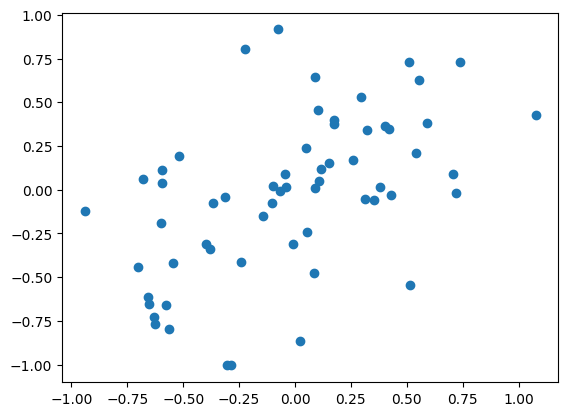

In [240]:
plt.scatter(student_models["additive_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["additive_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

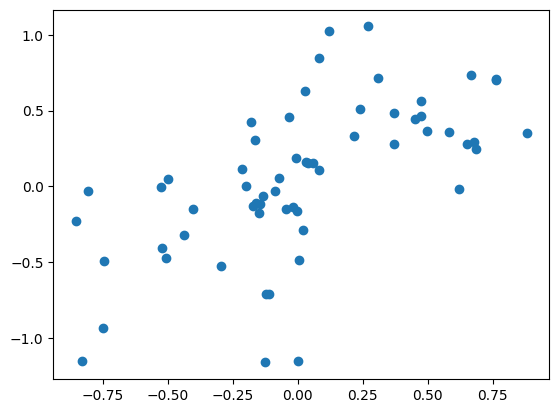

In [242]:
plt.scatter(student_models["rank_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["rank_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

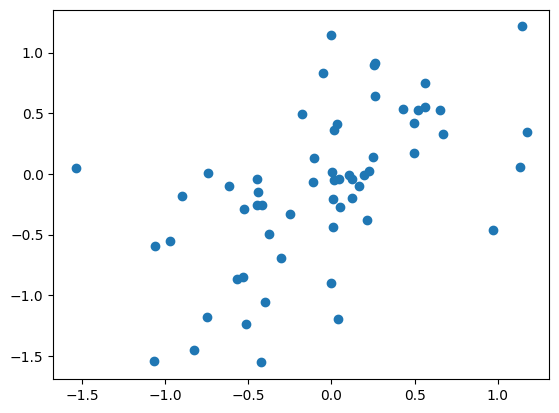

In [243]:
plt.scatter(student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 0].detach().numpy(), student_models["postsynaptic_presynaptic"].rnn.transition.A[:, 1].detach().numpy())

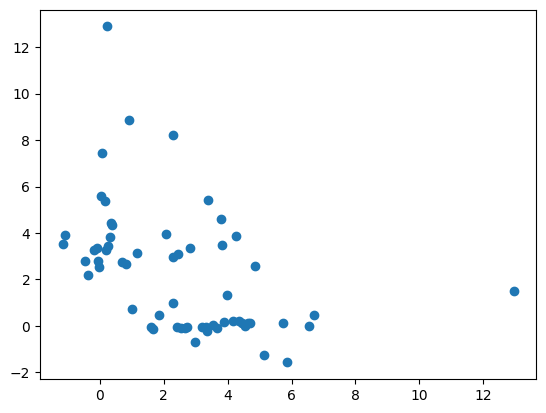

In [241]:
plt.scatter(teachers["presynaptic"].rnn.A[:, 0].detach().numpy(), teachers["presynaptic"].rnn.A[:, 1].detach().numpy())

Text(0.5, 1.0, 'Recovering neuromodulation weights')

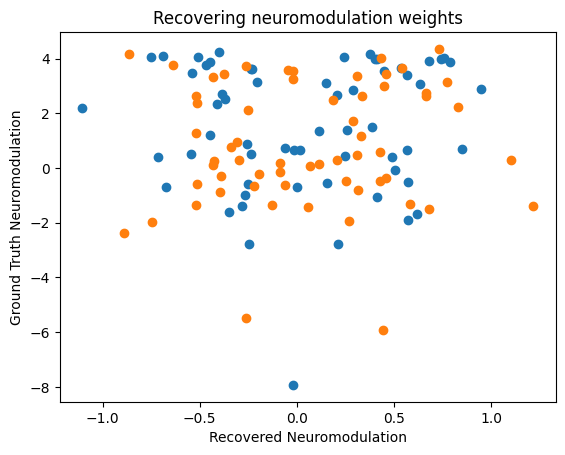

In [232]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 0].detach().cpu().numpy(), teachers["postsynaptic"].rnn.A[:, 0].detach().numpy())
plt.scatter(student_models["postsynaptic_postsynaptic"].rnn.transition.A[:, 1].detach().cpu().numpy(), teachers["postsynaptic"].rnn.A[:, 1].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

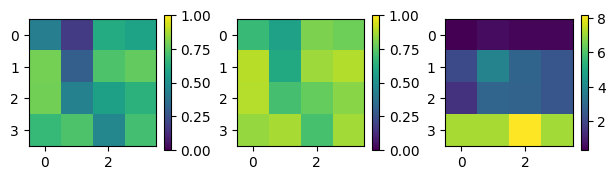

In [71]:
def plot_trial_averaged_traces(tch, tch_idx, num_neurons, cond, stud, figsize=(8, 15)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[tch_idx, cond, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, cond, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])
    plt.tight_layout()

def plot_raw_traces(tch, tch_idx, trial_idx, num_neurons, stud, figsize=(6, 6)):
    num_rows, num_cols = num_neurons, 5
    fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
    c = ['r', 'g', 'blue', 'black', 'orange']
    column_titles = ["Ground Truth", "Additive", "Rank", "Presynaptic", "Postsynaptic"]
    # Set titles for the top row
    for col, title in enumerate(column_titles):
        ax[0, col].set_title(title, fontsize=12)
    for i in range(num_rows):
        ax[i, 0].plot(tch[trial_idx, :, i], c=c[0])
        for j in range(len(neuromodulation_mechanisms)):
            ax[i, j+1].plot(stud[tch_idx, j, trial_idx, :, i], label=neuromodulation_mechanisms[j], c=c[j+1])
    plt.tight_layout()

## Rank Neuromodulation

### Visualize some raw traces

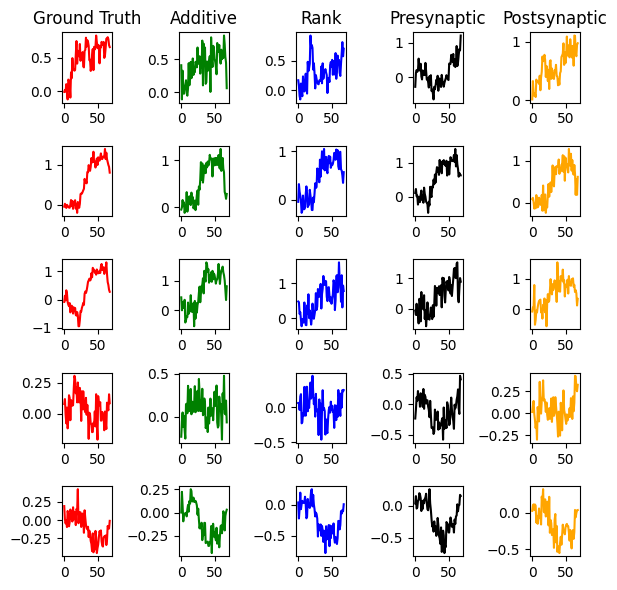

In [75]:
plot_raw_traces(teacher_tasks["rank"].data, tch_idx=1, trial_idx=1, num_neurons=5, stud=predictions)

### Look at the trial averaged traces

#### Teacher: Rank Modulated RNN. Condition 0 trial-averaged traces

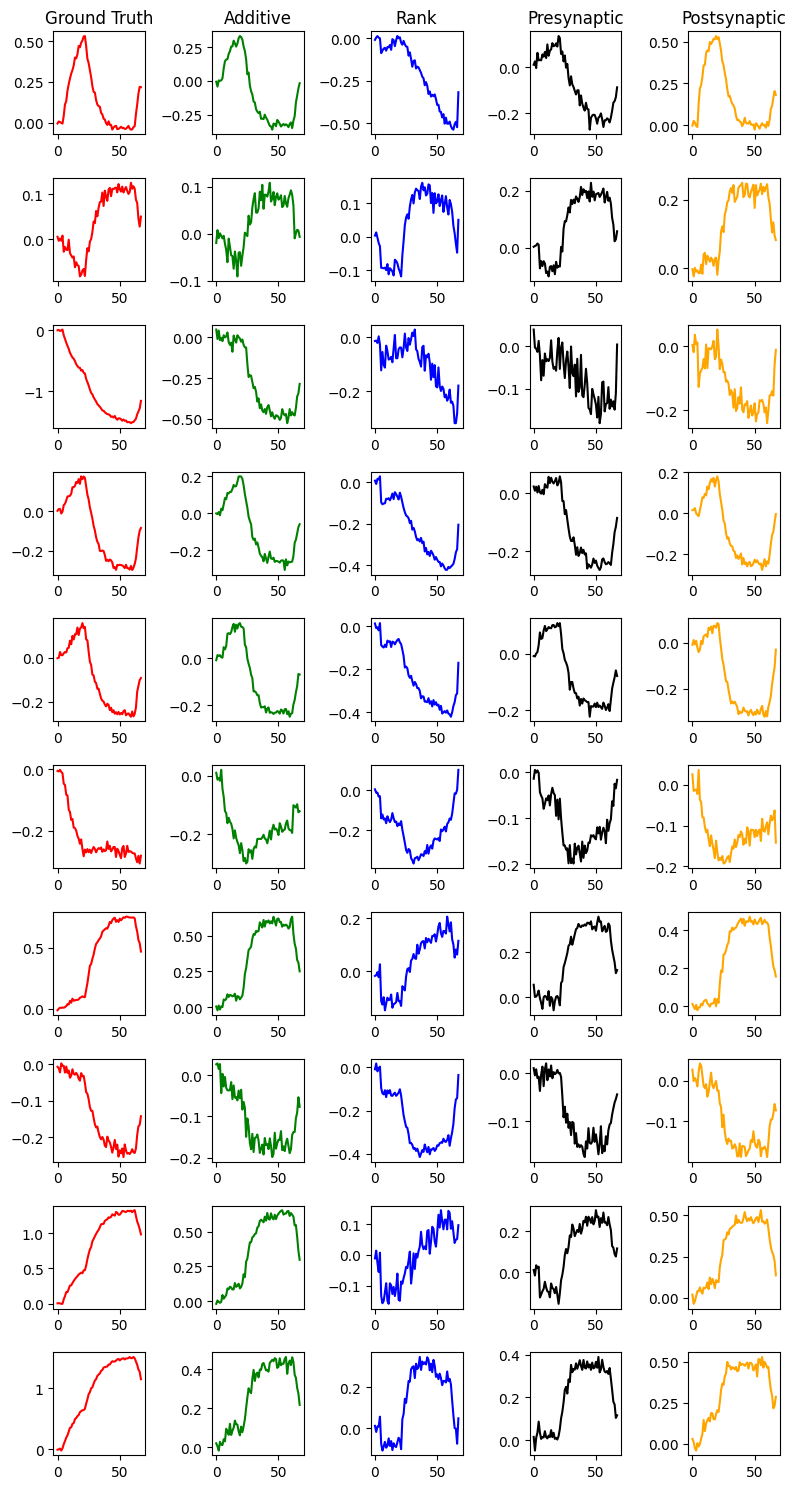

In [98]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 1 trial-averaged traces

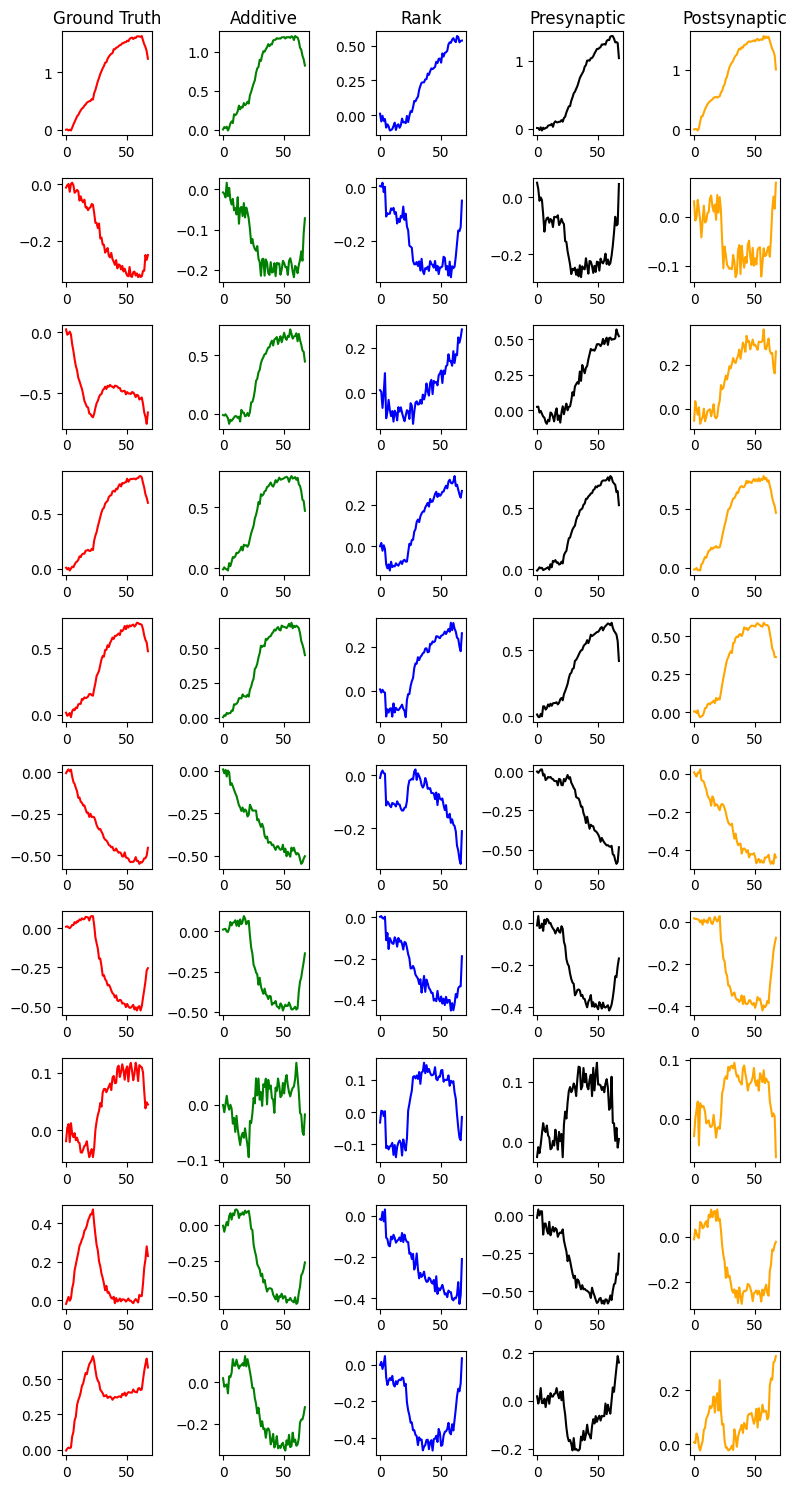

In [99]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 2 trial-averaged traces

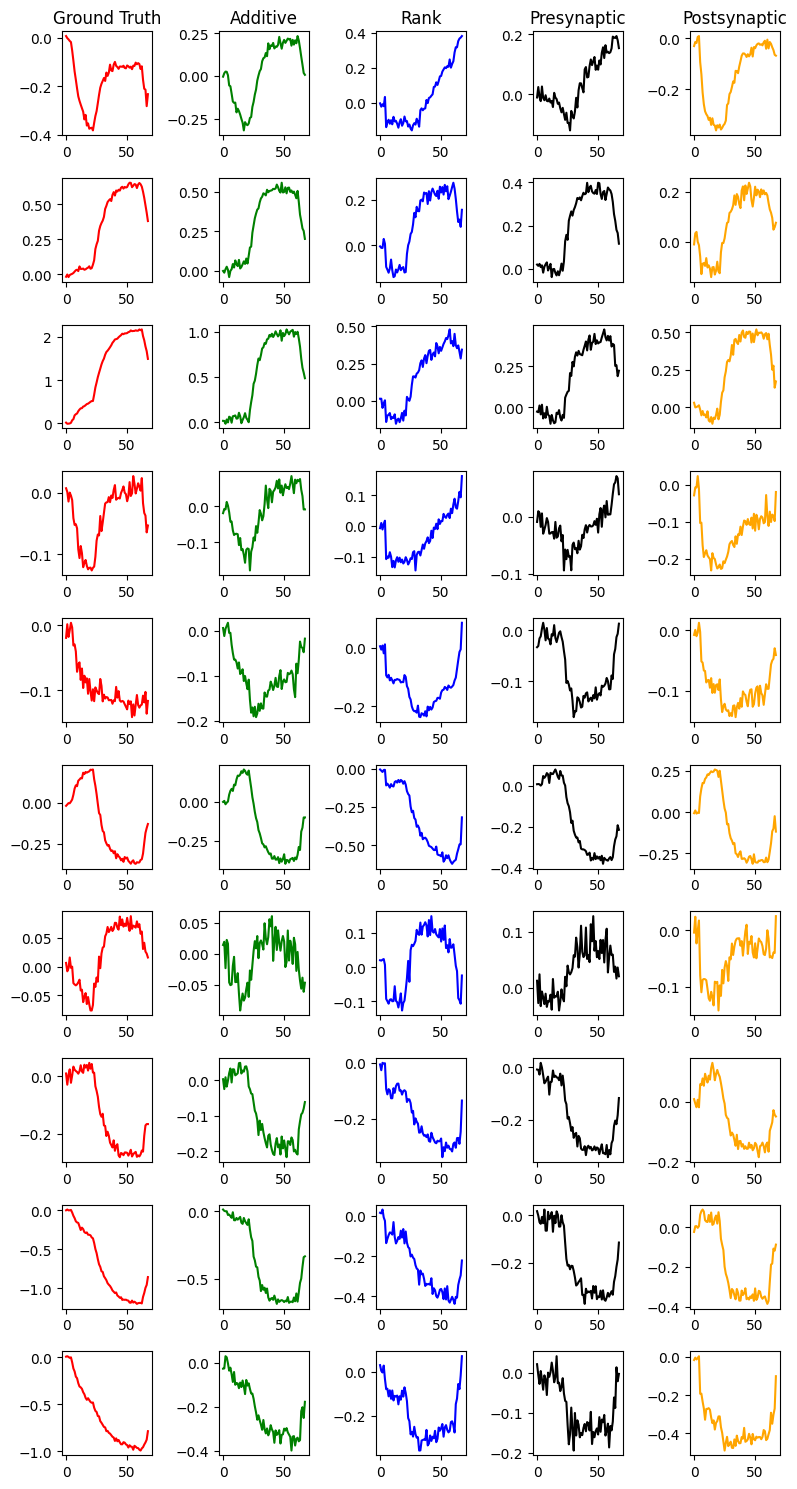

In [ ]:
plot_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Rank Modulated RNN. Condition 3 trial-averaged traces

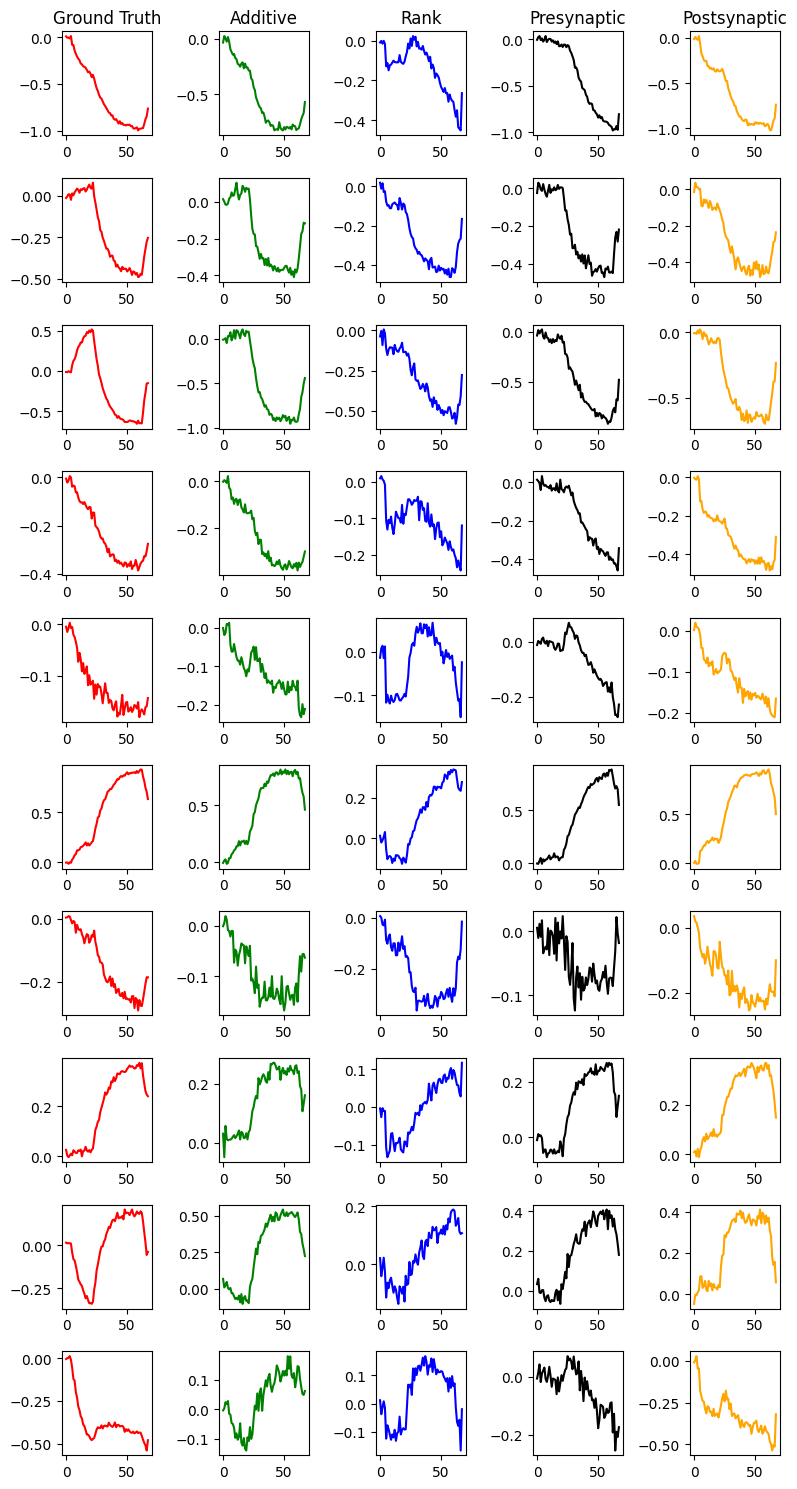

In [66]:
plot_traces(tch=tch_trial_avgs, tch_idx=1, num_neurons=10, cond=3, stud=std_trial_avgs)

## Additive Neuromodulation

#### Teacher: Additive Modulated RNN. Some raw single-trial traces

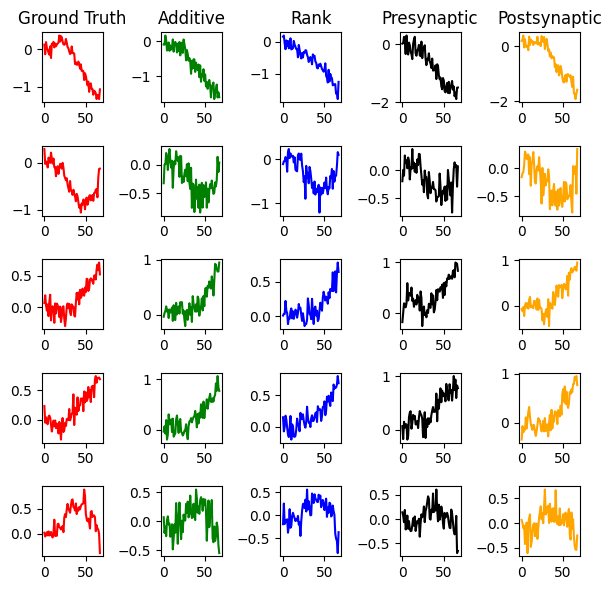

In [81]:
plot_raw_traces(tch=teacher_tasks["additive"].data, tch_idx=0, trial_idx=0, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Additive modulated RNN. Condition 0

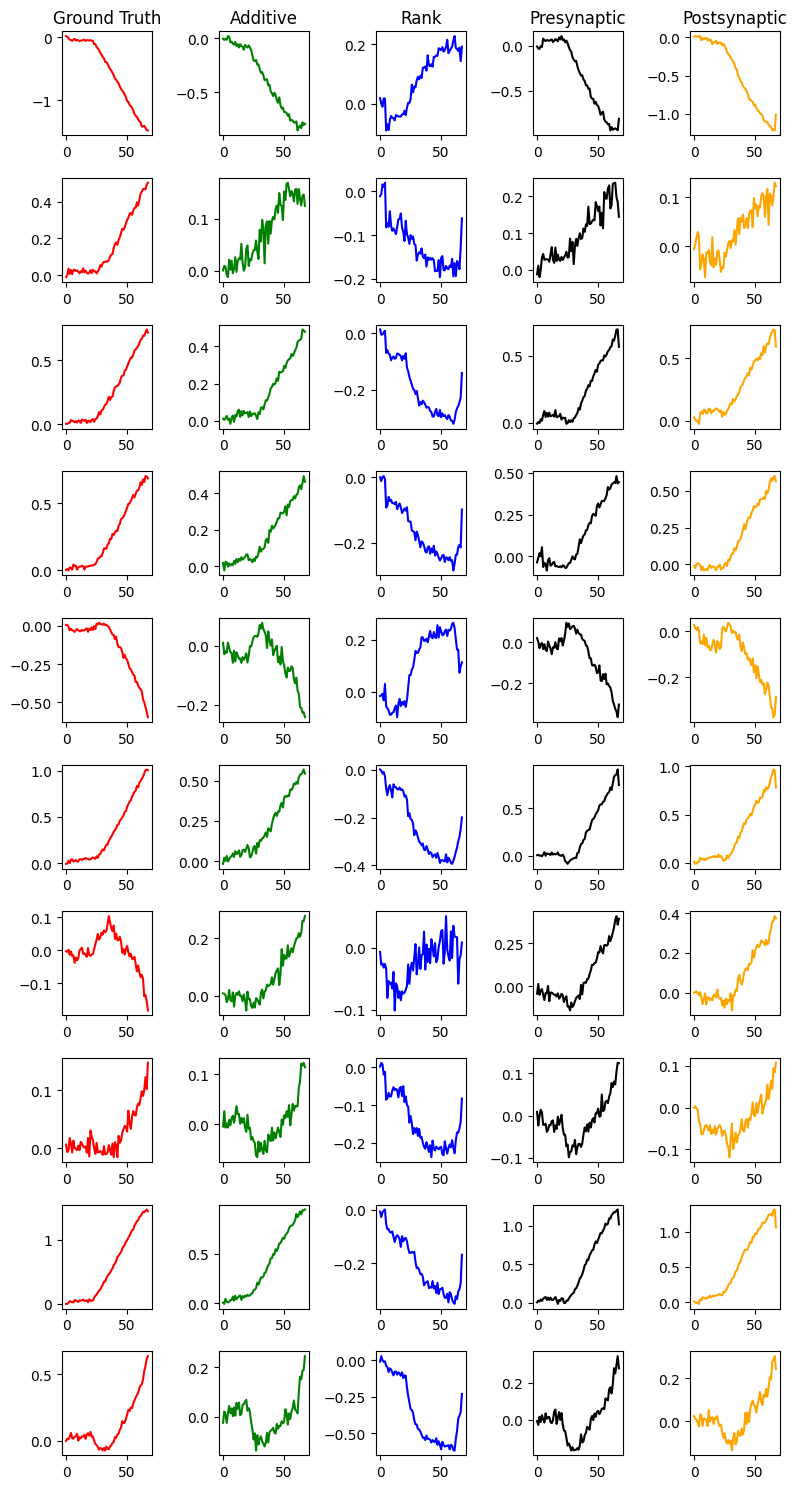

In [79]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 1

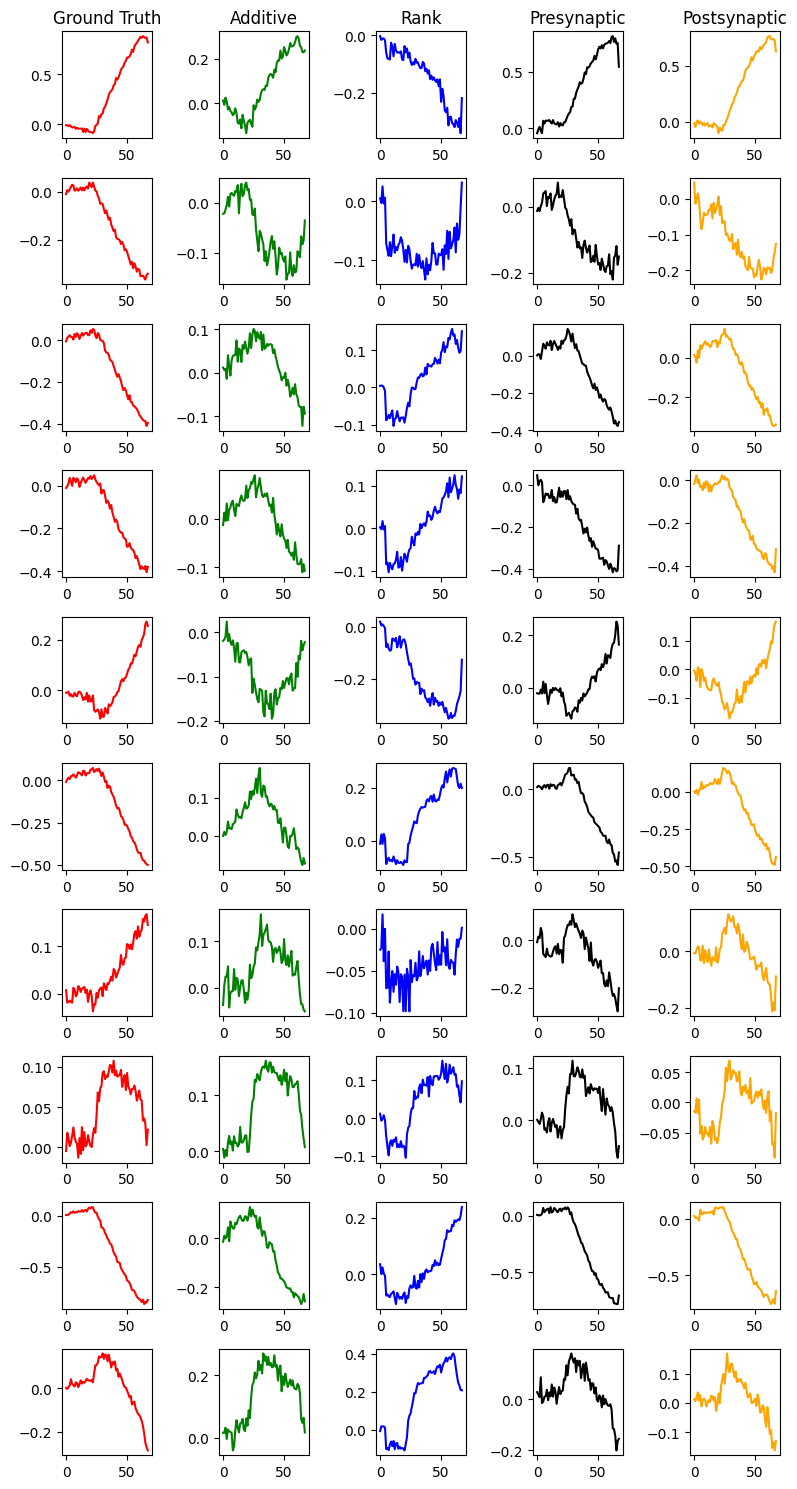

In [84]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 2

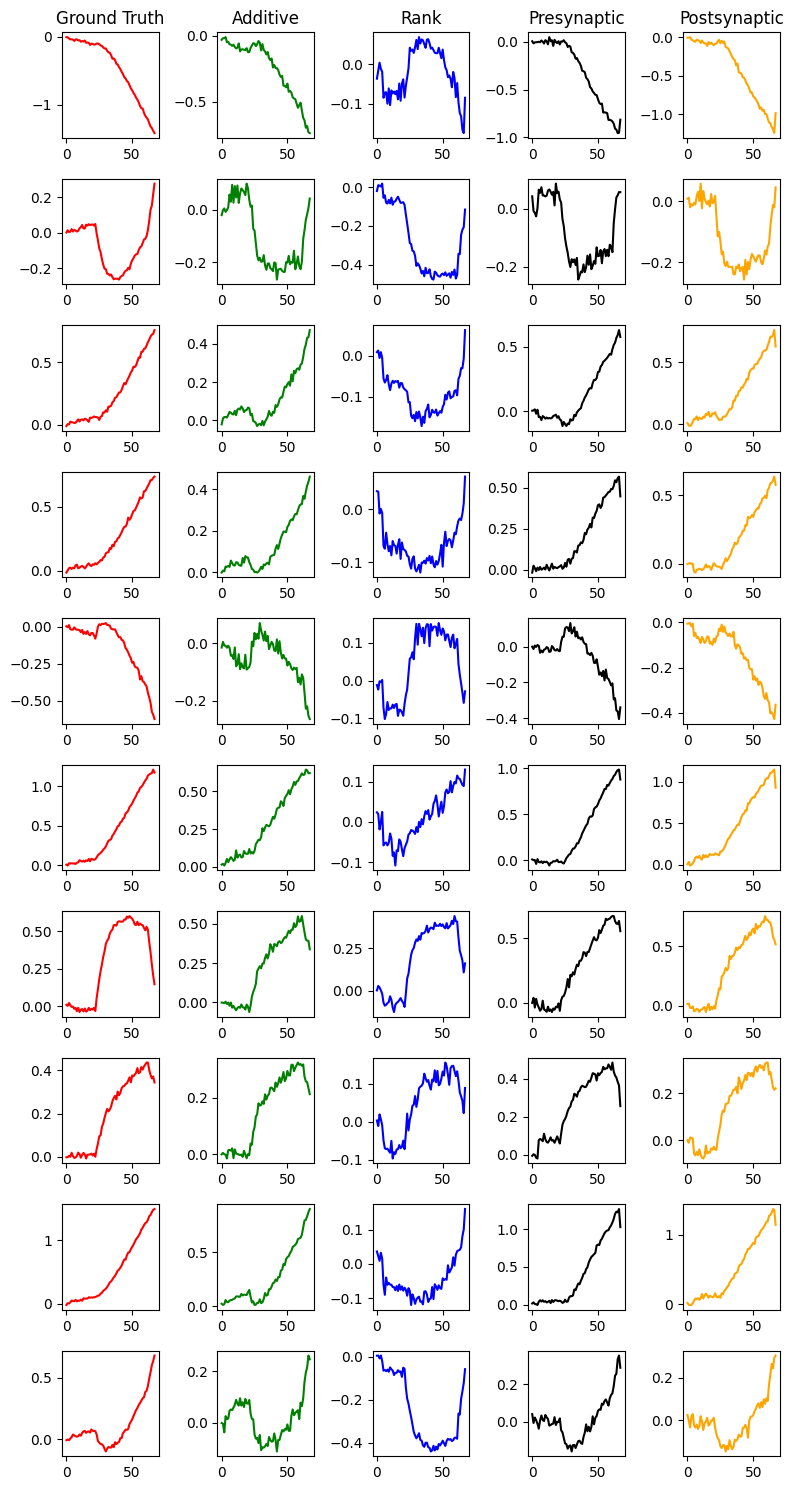

In [85]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Additive modulated RNN. Condition 3

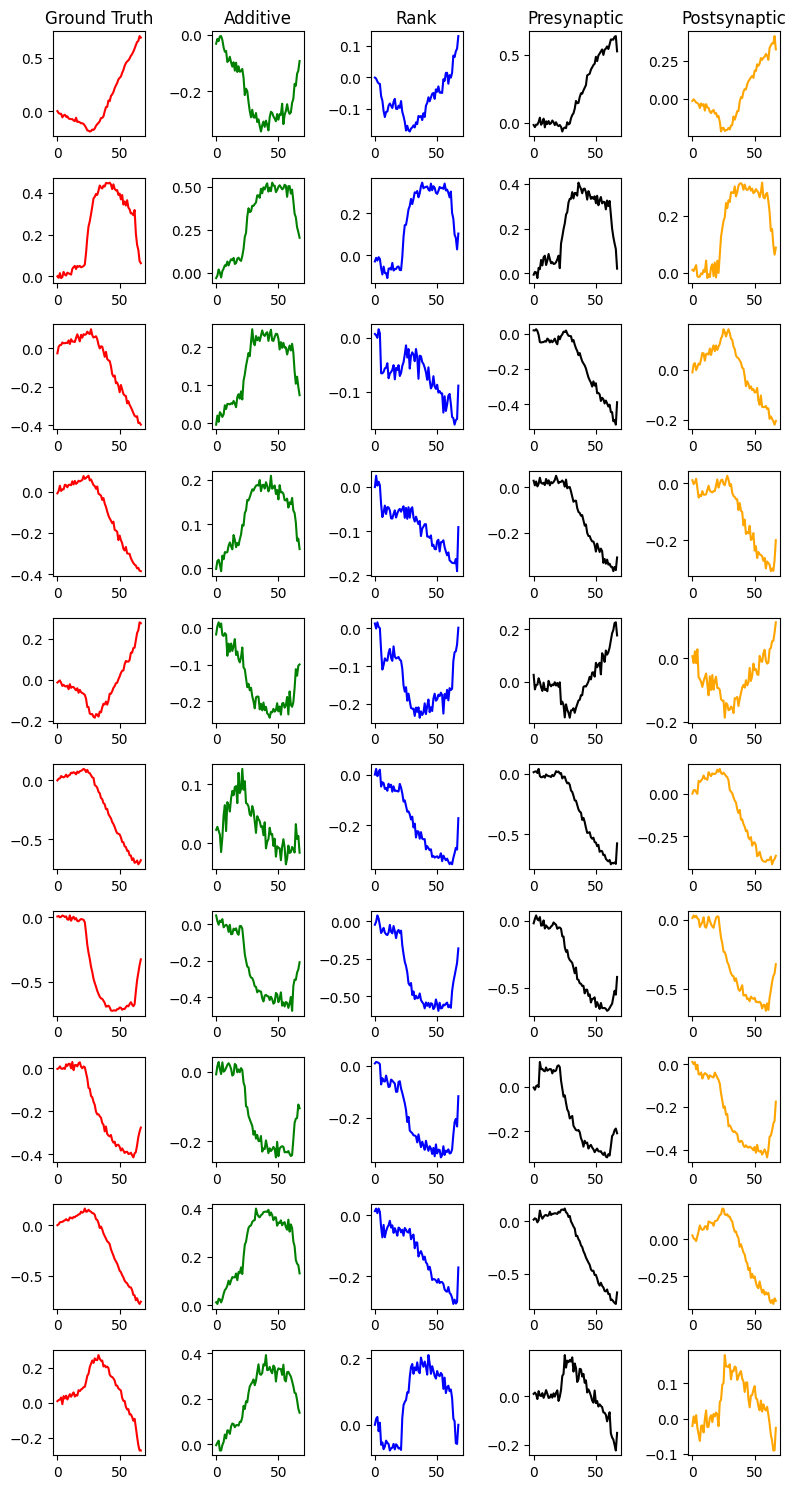

In [86]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=0, num_neurons=10, cond=3, stud=std_trial_avgs)

## Postsynaptic Neuromodulation

#### Some single-trial traces

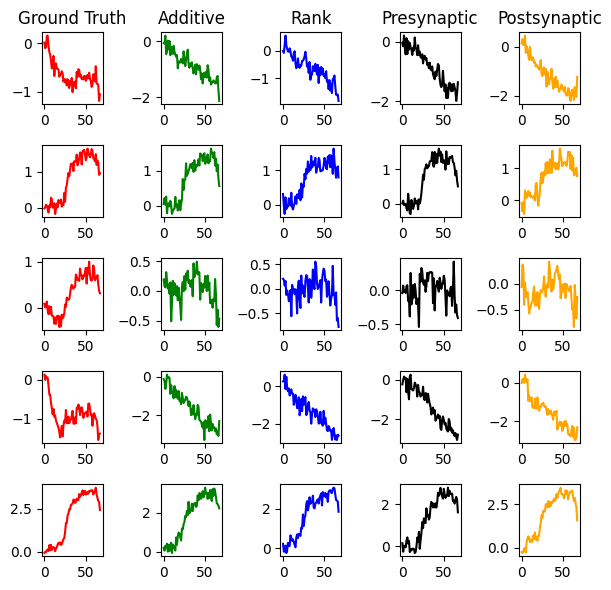

In [87]:
plot_raw_traces(teacher_tasks["postsynaptic"].data, tch_idx=3, trial_idx=1, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Postsynaptic modulated RNN. Condition 0

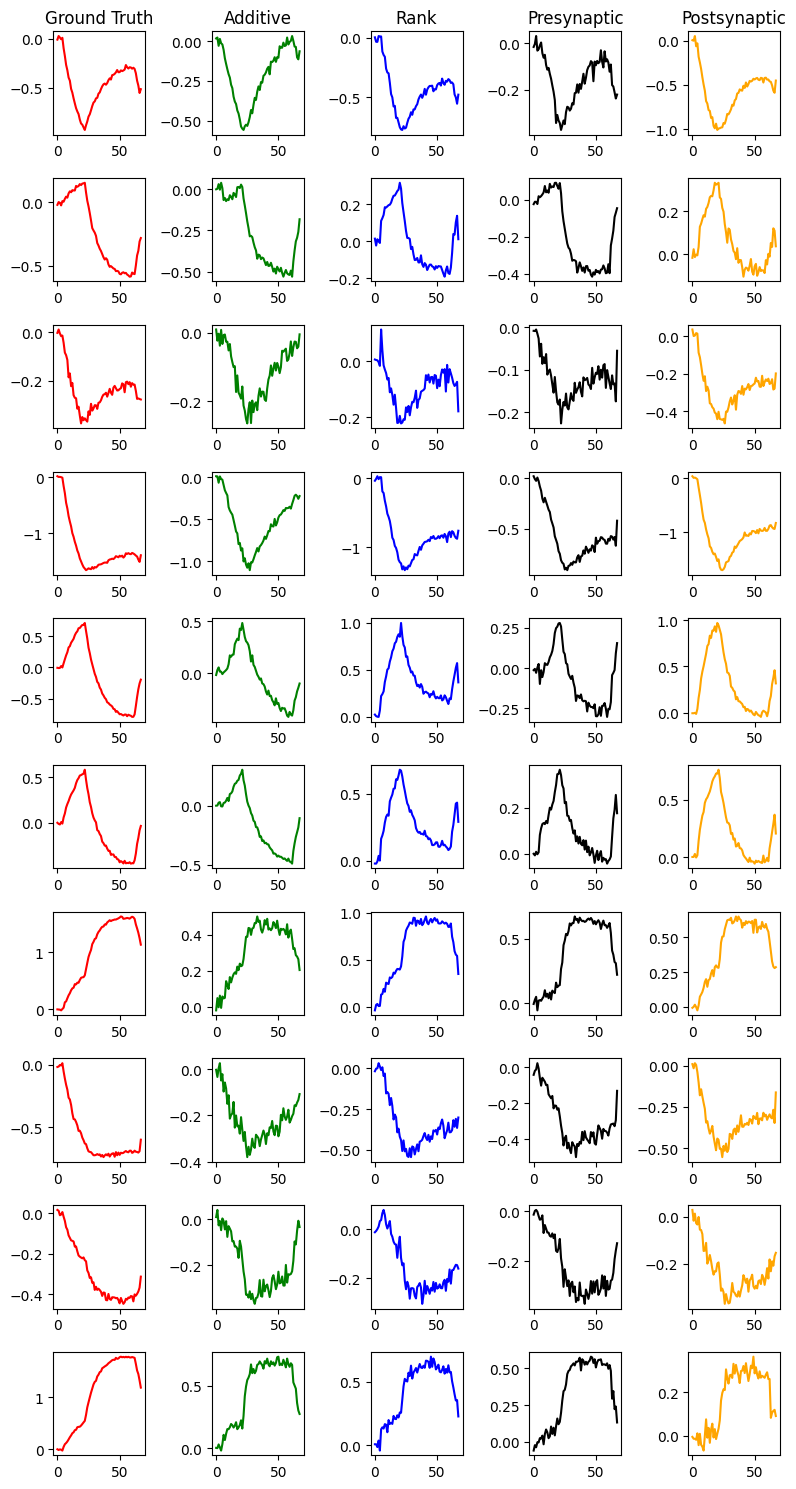

In [89]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 1

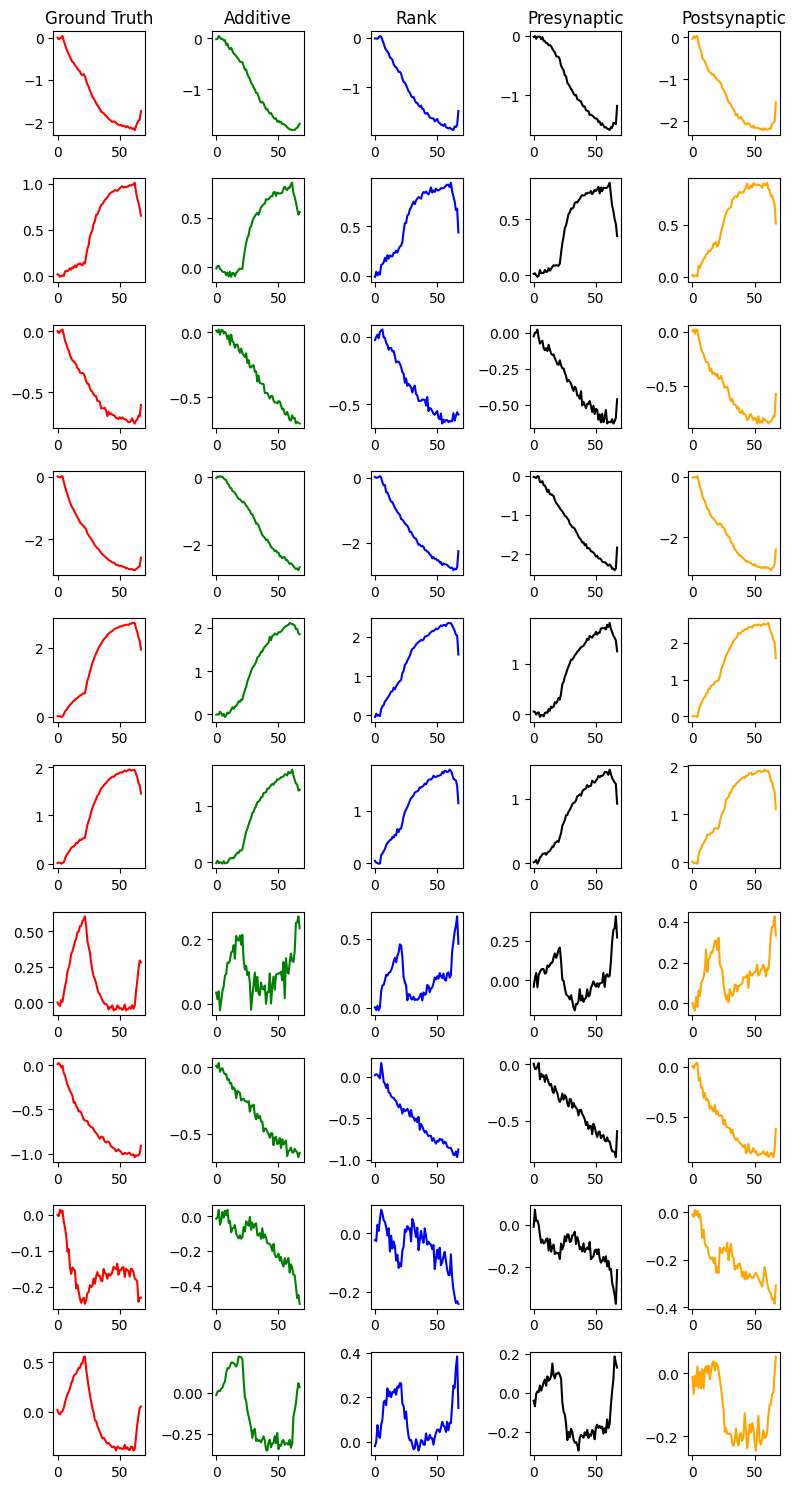

In [90]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 2

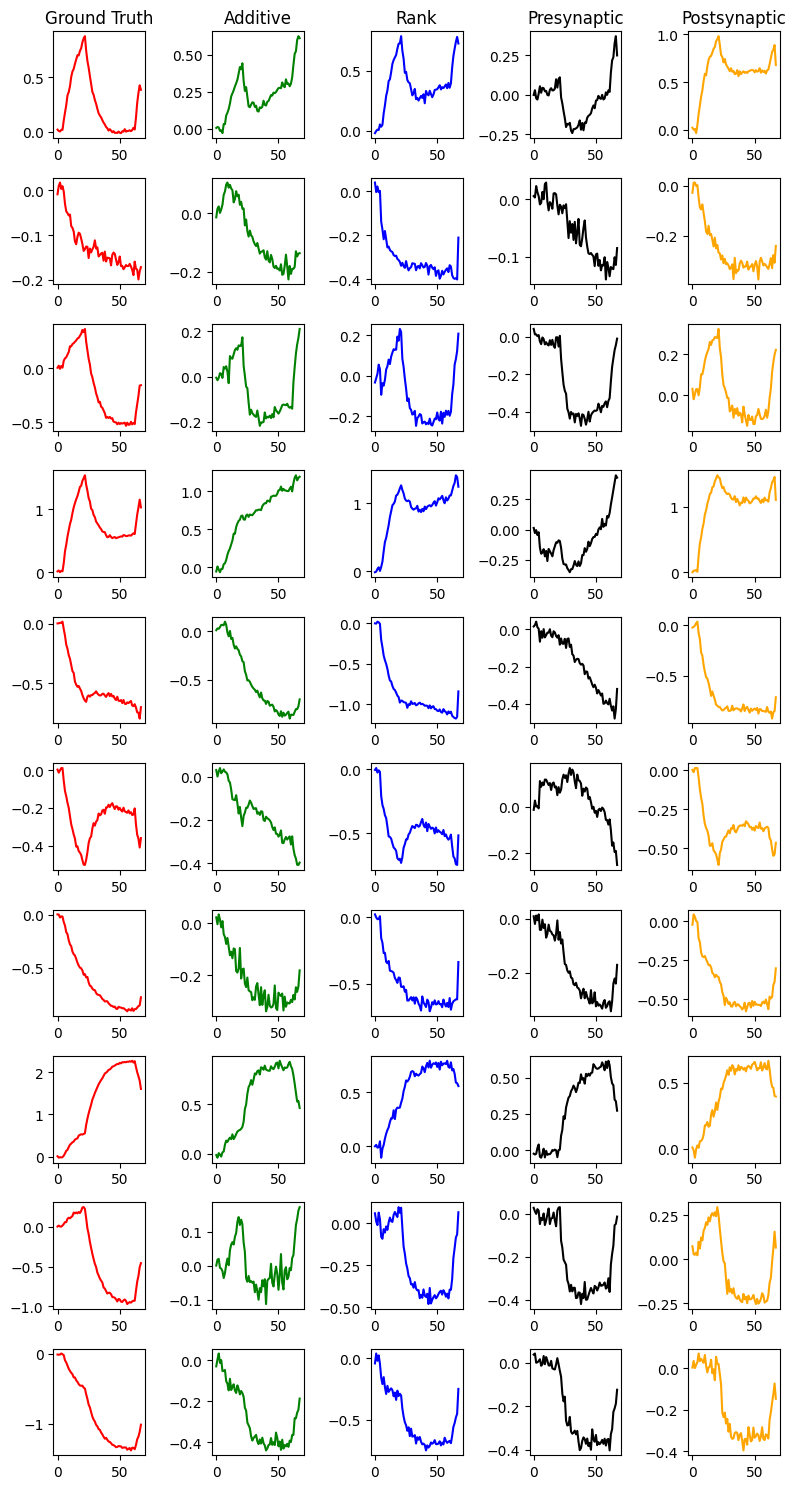

In [91]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Postsynaptic modulated RNN. Condition 3

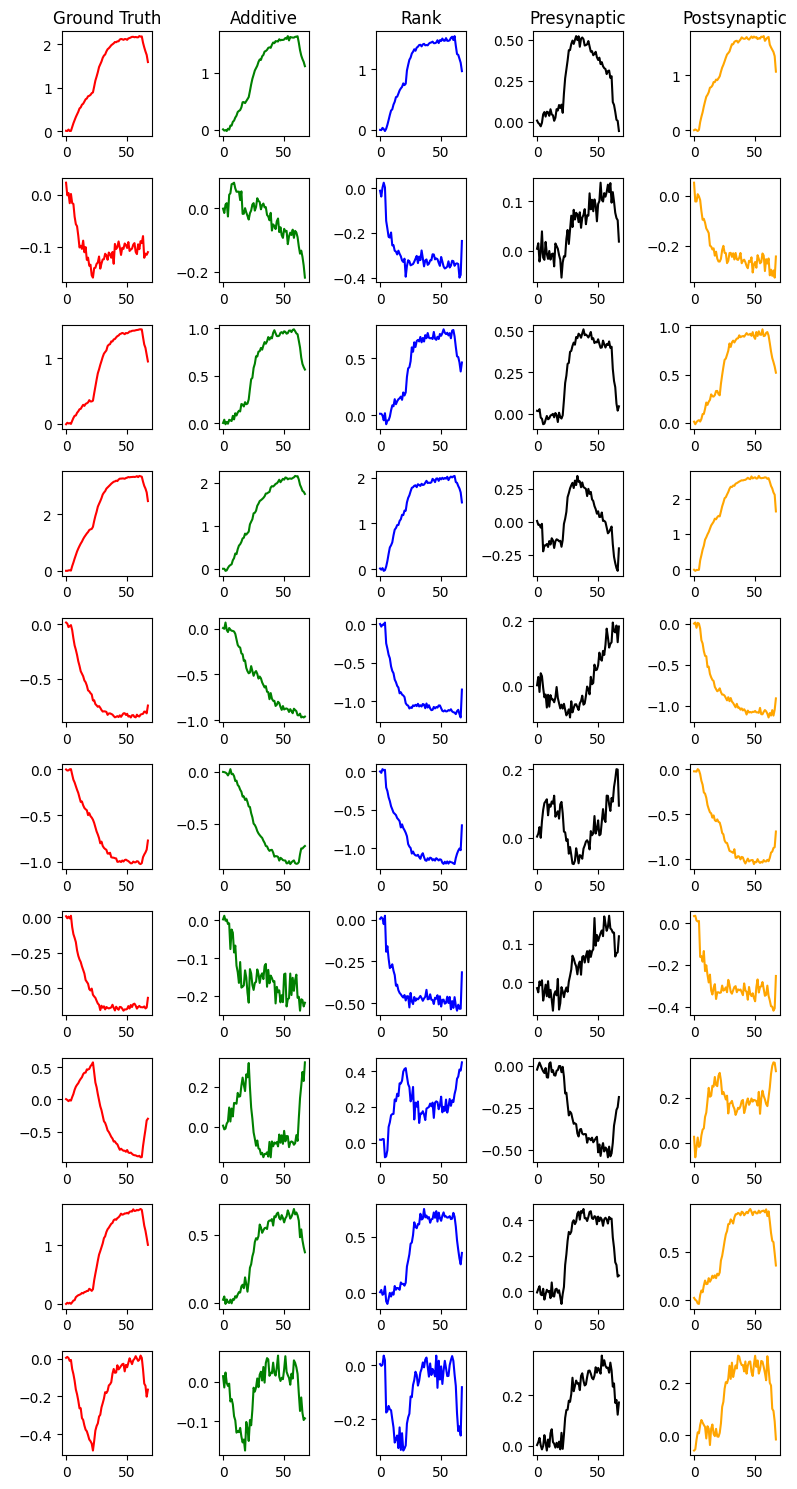

In [92]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=3, num_neurons=10, cond=3, stud=std_trial_avgs)

## Teacher: Presynaptic Neuromodulation

#### Some single-trial traces

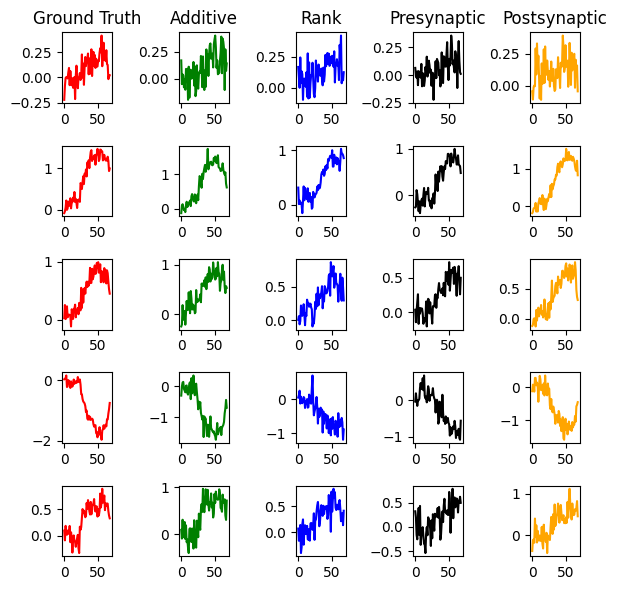

In [100]:
plot_raw_traces(teacher_tasks["presynaptic"].data, tch_idx=2, trial_idx=1, num_neurons=5, stud=predictions)

### Trial averaged traces

#### Teacher: Presynaptic modulated RNN. Condition 0

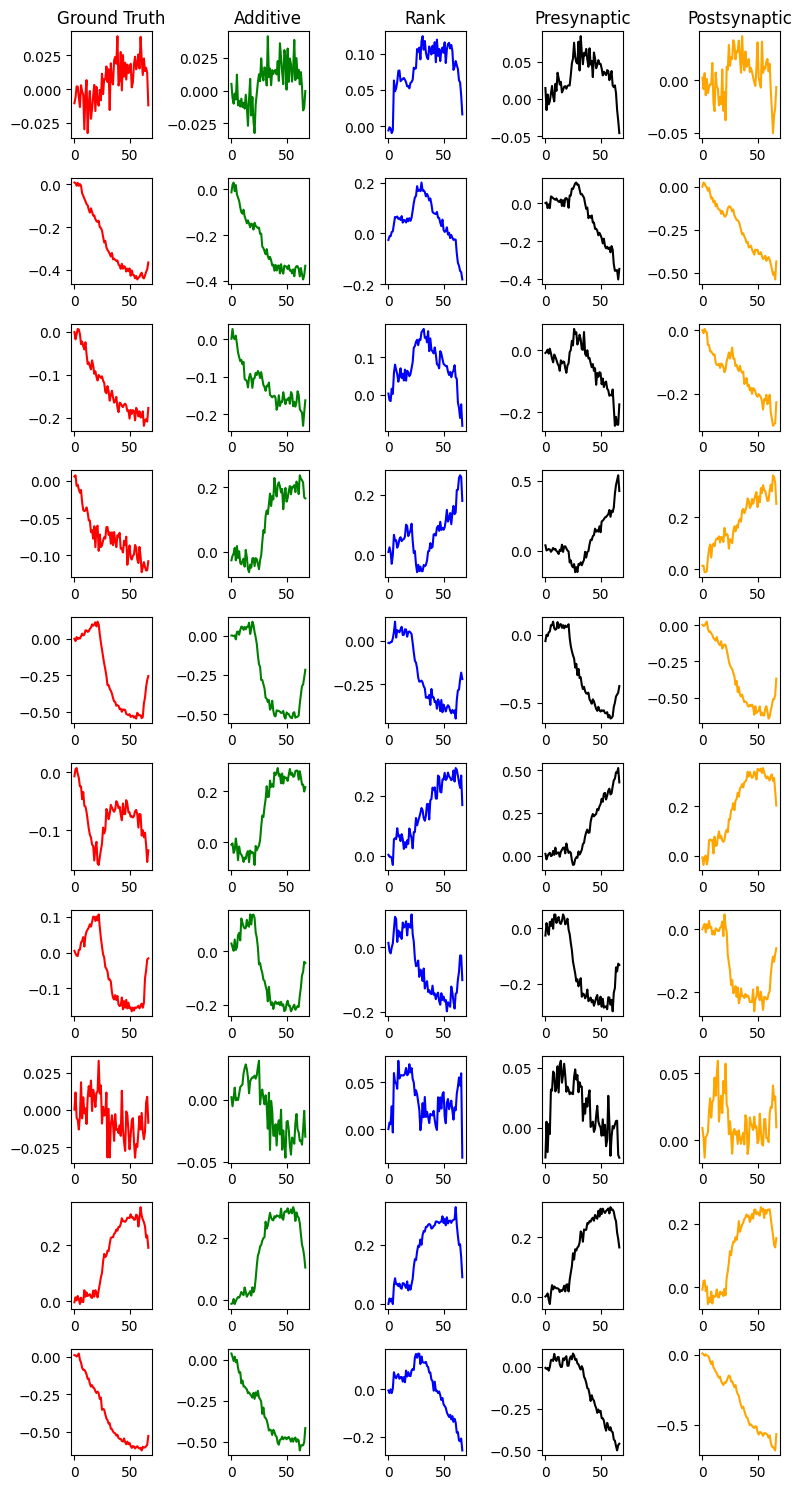

In [94]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=0, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 1

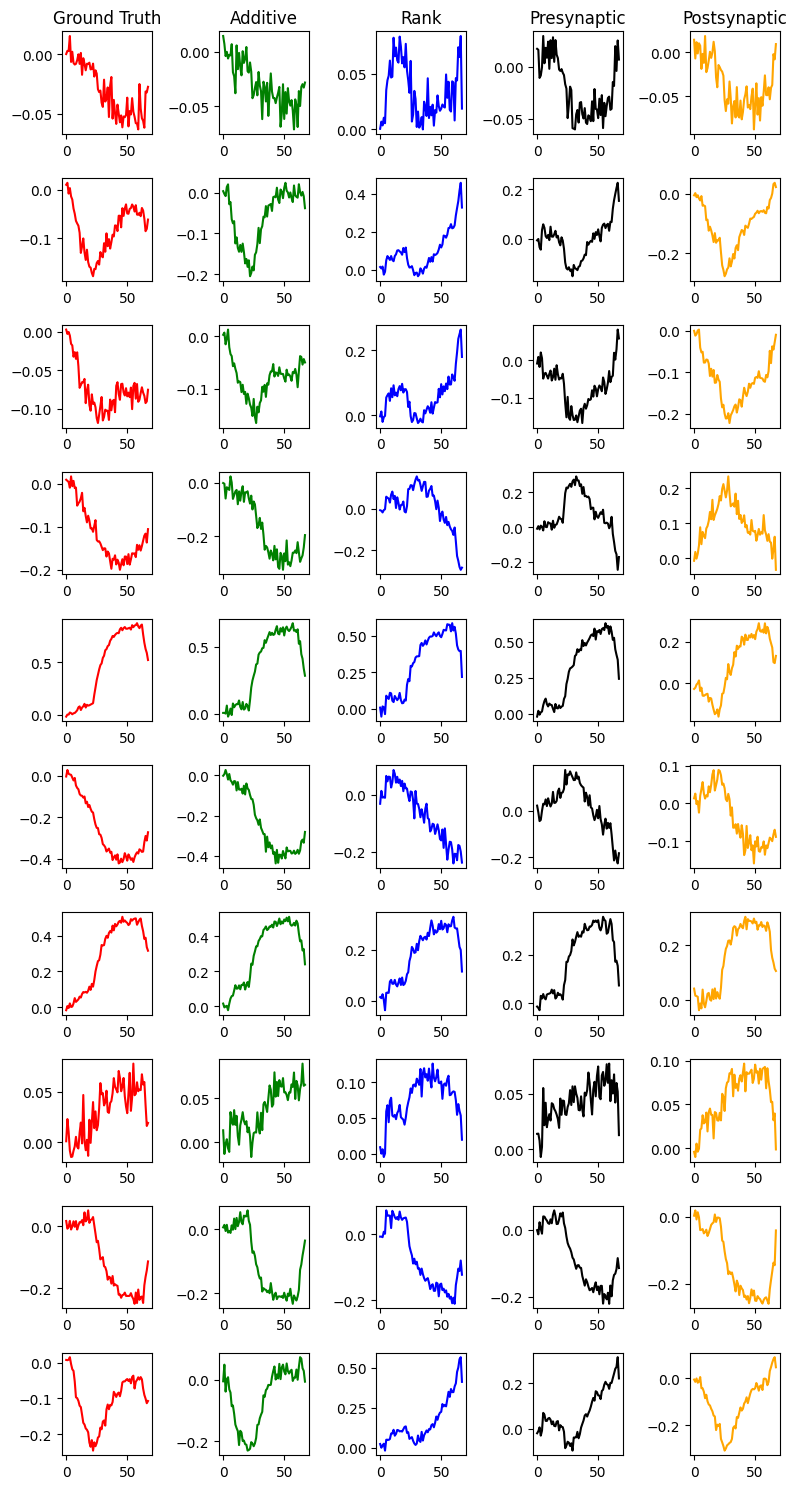

In [101]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=1, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 2

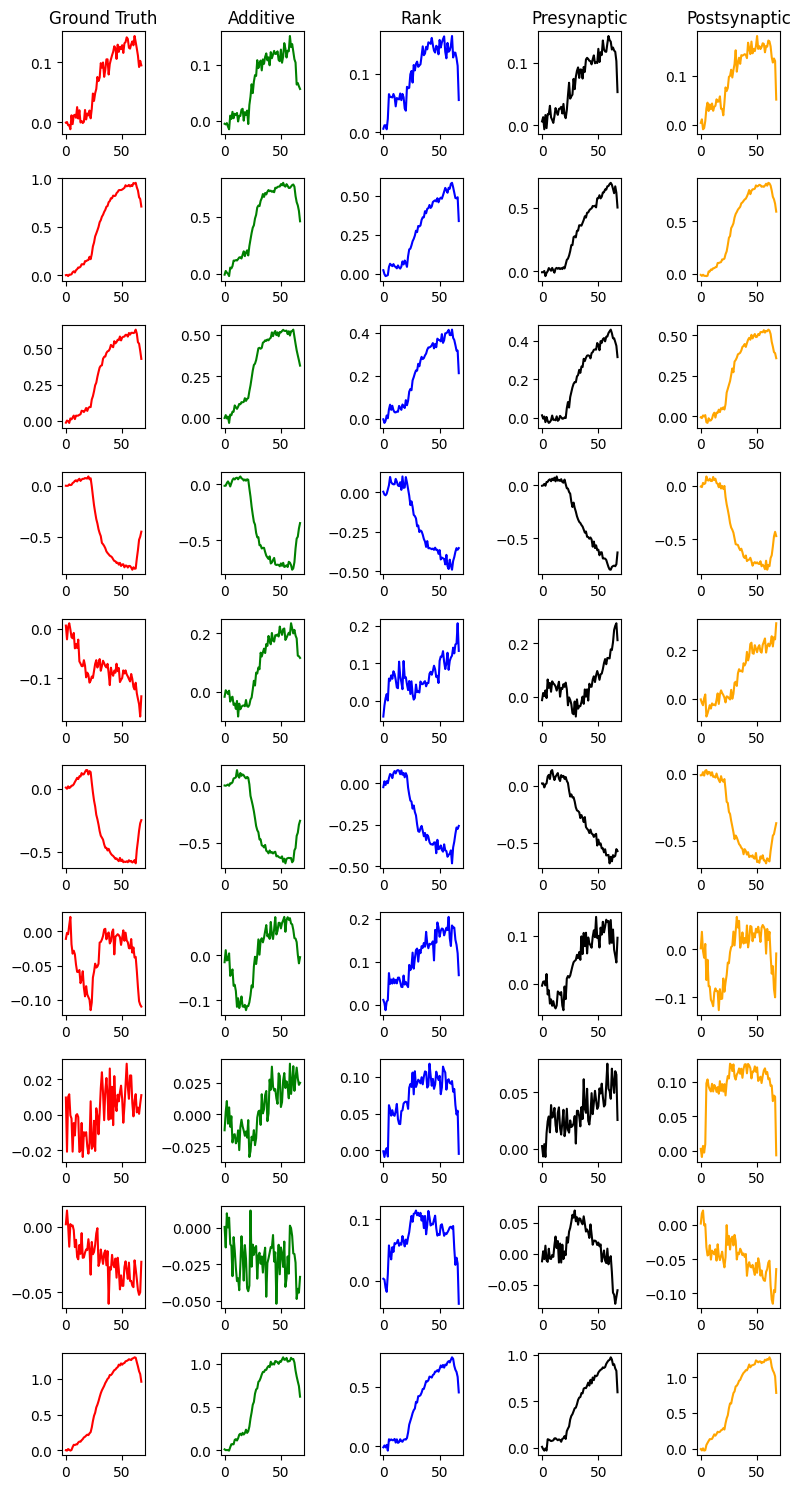

In [96]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=2, stud=std_trial_avgs)

#### Teacher: Presynaptic modulated RNN. Condition 3

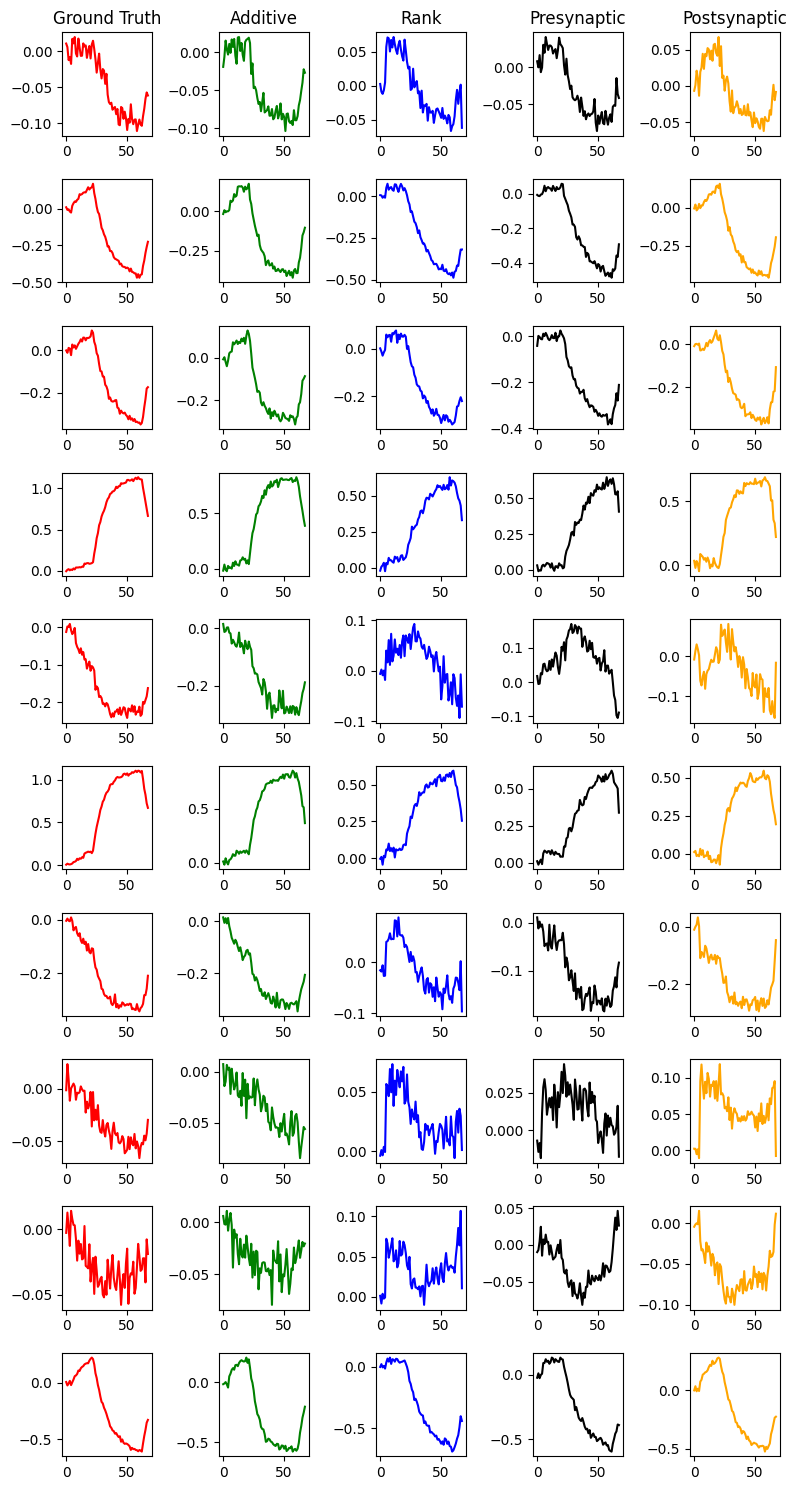

In [97]:
plot_trial_averaged_traces(tch=tch_trial_avgs, tch_idx=2, num_neurons=10, cond=3, stud=std_trial_avgs)